# W&B Sweep — Actor-Critic (AC)
Búsqueda de hiperparámetros para el agente AC en el ambiente Complejo (ORCH).
- Método: Random Search
- Proyecto W&B: `Tesis_AC_ORCH_TEST_4`
- Arquitectura: compleja (ORCH+CTRL)
- Acción: continua

CAMBIOS IMPORTANTES DE ARQ!
En esta notebook pruebo por cuarta vez trabajar con diferentes frecuencias entre el orch y ctrl, de modo que ctrl no colapse, y orch reciba informacion mas fidedigna, pero ademas, dado que en la primera se observo que el critic=0, se debieron realizar varias modificacionses:

* ajustar el reward para que vaya acorde con la nueva frecuencia de orch
* realizar este cambio solo para orch no ctrl
* normalizar el error_integral a entre -1y 1 ya que el mismo tiende a explotar por el efecto windup.

*En esta cuarta version, el cambio fundamental es en reward, donde se modifica el calculo especialmente para orch

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1601, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 1601 (delta 95), reused 114 (delta 52), pack-reused 1440 (from 1)
Receiving objects: 100% (1601/1601), 34.43 MiB | 21.42 MiB/s, done.
Resolving deltas: 100% (959/959), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU')
else:
    print(gpu_info)

Wed Mar 18 22:55:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   27C    P0             45W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Login W&B

In [4]:
!pip install wandb --quiet

In [5]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [ ]:
# ============ CONSTANTES FIJAS ============
WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_ORCH_GRID_TEST_4'
SEED          = 42
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

N_EPISODES    = 1500
EVAL_FREQUENCY               = 100
EARLY_STOPPING_PATIENCE      = 20       # más paciencia que antes (era 15)
EARLY_STOPPING_MIN_DELTA_PCT = 0.01

MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
DT = 1.0

# Parámetros de la nueva arquitectura HRL!!
ORCH_FREQ  = 30                         # steps del CTRL entre cada decisión del ORCH
N_DEC_ORCH = 8                          # decisiones del ORCH por episodio
MAX_STEPS  = ORCH_FREQ * N_DEC_ORCH    # = 240 steps globales del CTRL por episodio

AC_CTRL_CHECKPOINT = '/content/agent_ctrl_best.pt'

print(f'Device: {DEVICE}')
print(f'MAX_STEPS={MAX_STEPS} | ORCH_FREQ={ORCH_FREQ} | Decisiones ORCH/ep={N_DEC_ORCH}')

# ============ SWEEP CONFIG ============
sweep_config = {
    'name'  : 'ac_orch_hrl_v2',
    'method': 'grid',
    'metric': {'name': 'eval_reward', 'goal': 'maximize'},
    'parameters': {
        'orch_freq'   : {'values': [15,  30,  30,  30 ]},
        'batch_size'  : {'values': [64,  64,  128, 64 ]},
        'warmup_steps': {'values': [200, 200, 500, 500]},
        'buffer_size' : {'values': [10000, 10000, 50000, 10000]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f'Sweep creado: {sweep_id}')

Device: cuda
MAX_STEPS=240 | ORCH_FREQ=30 | Decisiones ORCH/ep=8
Create sweep with ID: pfrlsr93
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/sweeps/pfrlsr93
Sweep creado: pfrlsr93


## 4. Función del Sweep

In [ ]:
def sweep_run():
    wandb.init()
    cfg = wandb.config

    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    wandb.config.update({'seed': SEED}, allow_val_change=True)

    # MAX_STEPS depende del orch_freq de este run
    max_steps_run = cfg.orch_freq * N_DEC_ORCH

    trainer_config = {
        'env_config': {
            'architecture'             : 'jerarquica',
            'env_type'                 : 'simulation',
            'n_manipulable_vars'       : 2,
            'manipulable_ranges'       : MANIPULABLE_RANGES,
            'n_target_vars'            : 1,
            'target_ranges'            : [(0.0, 1.0)],
            'target_setpoints'         : [0.4],
            'target_working_ranges'    : [(0.0, 2.0)],
            'dt_usuario'               : DT,
            'max_steps'                : max_steps_run,     # ← ahora depende de orch_freq
            'orch_freq'                : cfg.orch_freq,     # ← NUEVO
            'max_time_detector'        : 120,
            'reward_dead_band'         : 0.02,
            'delta_percent_ctrl'       : 0.05,
            'delta_percent_orch'       : 0.05,
            'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
            'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
            'agent_orchestrator_config': {'agent_type': 'continuous'},
            'env_type_config'          : {'dt': DT, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
            'stability_config'         : {
                'error_increase_tolerance': 2.0,
                'max_sign_changes_ratio'  : 0.2,
                'max_abrupt_change_ratio' : 0.05,
                'abrupt_change_threshold' : 0.5,
            },
        },

        'ctrl_checkpoint_path': AC_CTRL_CHECKPOINT,
        'agent_ctrl_config': {
            'algorithm'  : 'ac',
            'state_dim'  : 10,
            'action_dim' : 6,
            'n_vars'     : 2,
            'action_type': 'continuous',
            'hidden_dims': (256, 128, 64),
            'device'     : DEVICE,
        },

        'agent_orch_config': {
            'algorithm'    : 'ac',
            'state_dim'    : 5,
            'action_dim'   : 3,
            'n_vars'       : 2,
            'action_type'  : 'continuous',
            'hidden_dims'  : (64, 32),
            'lr_actor'     : 1e-05,
            'lr_critic'    : 1e-03,
            'gamma'        : 0.99,
            'entropy_coef' : 0.05,
            'batch_size'   : cfg.batch_size,
            'buffer_size'  : cfg.buffer_size,
            'warmup_steps' : cfg.warmup_steps,
            'device'       : DEVICE,
            'seed'         : SEED,
        },

        'n_episodes'                  : N_EPISODES,
        'max_steps_per_episode'       : max_steps_run,      # ← alineado con el ambiente
        'eval_frequency'              : EVAL_FREQUENCY,
        'log_frequency'               : 50,
        'save_frequency'              : 9999,
        'checkpoint_dir'              : f'checkpoints/ac_orch_hrl_{wandb.run.name}',
        'early_stopping_patience'     : EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
        'use_wandb'                   : True,
    }

    cstr = CSTRSimulator(dt=DT, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
    trainer = ACTrainer(trainer_config)
    trainer.env.proceso.connect_external_process(cstr)
    trainer.train()

    # Guardar pesos en W&B
    checkpoint_path = f'checkpoints/ac_orch_hrl_{wandb.run.name}'
    if os.path.exists(checkpoint_path):
        artifact = wandb.Artifact(
            name        = f'model_{wandb.run.name}',
            type        = 'model',
            description = f'AC ORCH HRL v2 - {wandb.run.name}',
            metadata    = {
                'orch_freq'   : cfg.orch_freq,
                'max_steps'   : max_steps_run,
                'batch_size'  : cfg.batch_size,
                'warmup_steps': cfg.warmup_steps,
                'buffer_size' : cfg.buffer_size,
            }
        )
        artifact.add_dir(checkpoint_path)
        wandb.log_artifact(artifact)
        print(f'Pesos guardados en W&B')

    wandb.log({
        'final_eval_reward'       : trainer.best_reward,
        'total_episodes'          : len(trainer.episode_rewards),
        'final_reward_mean10'     : np.mean(trainer.episode_rewards[-10:]),
        'final_critic_loss_mean10': np.mean(trainer.critic_losses[-10:]) if trainer.critic_losses else 0,
        'orch_freq'               : cfg.orch_freq,          # ← para comparar runs en W&B
        'n_dec_orch_per_ep'       : N_DEC_ORCH,
    })

    run_name = wandb.run.name   # guardar antes de finish(), después es None
    wandb.finish()
    print(f'Run completado: {run_name}')

## 5. Lanzar Sweep

In [ ]:
wandb.agent(sweep_id, function=sweep_run, count=4)

wandb: Agent Starting Run: lwttrp2n with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 10000
wandb: 	orch_freq: 15
wandb: 	warmup_steps: 200
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cuda
AC Agent cargado desde: /content/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cuda

Episodio 0/1500
  Reward: -0.03 | Length: 120
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000
  ORCH Memory: 8

Episodio 50/1500
  Reward: -0.03 | Length: 120
  Actor Loss: -0.7600 | Critic Loss: 1.2931
  Advantage mean: -0.1646
  ORCH Memory: 408

Episodio 100/1500
  Reward: -0.00 | Length: 120
  Actor Loss: -0.6261 | Critic Loss: 3.8999
  Advantage mean: -0.1112
  ORCH Memory: 808


wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_expert-sweep-1)... Done. 0.0s


Evaluación: Reward promedio = -0.01
AC Agent guardado en: checkpoints/ac_orch_hrl_expert-sweep-1/agent_ctrl_best.pt
AC Agent guardado en: checkpoints/ac_orch_hrl_expert-sweep-1/agent_orch_best.pt
Checkpoint guardado: best

Episodio 150/1500
  Reward: -0.01 | Length: 120
  Actor Loss: -0.6700 | Critic Loss: 3.4701
  Advantage mean: -0.1159
  ORCH Memory: 1208

Episodio 200/1500
  Reward: -0.00 | Length: 120
  Actor Loss: -0.1913 | Critic Loss: 2.0471
  Advantage mean: 0.0035
  ORCH Memory: 1608
Evaluación: Reward promedio = -0.02
  Sin mejora: 1/20

Episodio 250/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -0.1037 | Critic Loss: 1.5518
  Advantage mean: 0.0382
  ORCH Memory: 2008

Episodio 300/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -0.1264 | Critic Loss: 2.2017
  Advantage mean: 0.0233
  ORCH Memory: 2408
Evaluación: Reward promedio = -0.02
  Sin mejora: 2/20

Episodio 350/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -0.4488 | Critic Loss: 2.5455
  Advantage mean: -0.0

wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_expert-sweep-1)... Done. 0.0s


...

Evaluación: Reward promedio = -0.00
  Sin mejora: 7/20
AC Agent guardado en: checkpoints/ac_orch_hrl_summer-sweep-4/agent_ctrl_best.pt
AC Agent guardado en: checkpoints/ac_orch_hrl_summer-sweep-4/agent_orch_best.pt
Checkpoint guardado: best

Episodio 850/1500
  Reward: -0.01 | Length: 240
  Actor Loss: -0.6668 | Critic Loss: 3.0133
  Advantage mean: -0.0957
  ORCH Memory: 6808

Episodio 900/1500
  Reward: -0.00 | Length: 240
  Actor Loss: -0.3558 | Critic Loss: 2.9607
  Advantage mean: -0.0087
  ORCH Memory: 7208
Evaluación: Reward promedio = -0.01
  Sin mejora: 8/20

Episodio 950/1500
  Reward: -0.00 | Length: 240
  Actor Loss: -0.4807 | Critic Loss: 4.4291
  Advantage mean: -0.0498
  ORCH Memory: 7608

Episodio 1000/1500
  Reward: -0.02 | Length: 240
  Actor Loss: -0.8688 | Critic Loss: 4.5984
  Advantage mean: -0.1273
  ORCH Memory: 8008
Evaluación: Reward promedio = -0.01
  Sin mejora: 9/20

Episodio 1050/1500
  Reward: -0.00 | Length: 240
  Actor Loss: -0.5805 | Critic Loss: 2.649

wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_summer-sweep-4)... Done. 0.0s


Pesos guardados en W&B


actor_loss,▆▄▅▅▄▄▄▇▄▄▇▄▃▅▅▄▅▆▇▃▄▆▃▆▁▅▃▄▃▆▃▄▃▅▆▄█▃▄▅
critic_loss,▁▁▁▁▁▃▂▃▃▃▃▃▂▃▃▂▃▃▅▃▃▄▄▄▄▄▄▃▄▄▄▅▄▄▂▅█▃▃▅
energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▅▃▄▆▂▅▄█▆▁▅▅▅▅
final_critic_loss_mean10,▁
final_eval_reward,▁
final_reward_mean10,▁
n_dec_orch_per_ep,▁
orch_freq,▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: summer-sweep-4


## Agrego dos corridas mas

In [ ]:
# ============ CONSTANTES FIJAS ============
WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_ORCH_GRID_TEST_4'
SEED          = 42
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

N_EPISODES    = 1500
EVAL_FREQUENCY               = 100
EARLY_STOPPING_PATIENCE      = 20       # más paciencia que antes (era 15)
EARLY_STOPPING_MIN_DELTA_PCT = 0.01

MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
DT = 1.0

# Parámetros de la nueva arquitectura HRL!!
ORCH_FREQ  = 30                         # steps del CTRL entre cada decisión del ORCH
N_DEC_ORCH = 8                          # decisiones del ORCH por episodio
MAX_STEPS  = ORCH_FREQ * N_DEC_ORCH    # = 240 steps globales del CTRL por episodio

AC_CTRL_CHECKPOINT = '/content/agent_ctrl_best.pt'

print(f'Device: {DEVICE}')
print(f'MAX_STEPS={MAX_STEPS} | ORCH_FREQ={ORCH_FREQ} | Decisiones ORCH/ep={N_DEC_ORCH}')

# ============ SWEEP CONFIG ============
sweep_config = {
    'name'  : 'ac_orch_hrl_v2',
    'method': 'grid',
    'metric': {'name': 'eval_reward', 'goal': 'maximize'},
    'parameters': {
        'orch_freq'   : {'values': [15,  15]},
        'batch_size'  : {'values': [64,  64]},
        'warmup_steps': {'values': [200, 200]},
        'buffer_size' : {'values': [10000, 10000]},
        'entropy_coef': {'values': [0.05, 0.01]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f'Sweep creado: {sweep_id}')

Device: cuda
MAX_STEPS=240 | ORCH_FREQ=30 | Decisiones ORCH/ep=8
Create sweep with ID: q1rqc05v
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/sweeps/q1rqc05v
Sweep creado: q1rqc05v


In [ ]:
def sweep_run():
    wandb.init()
    cfg = wandb.config

    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    wandb.config.update({'seed': SEED}, allow_val_change=True)

    # MAX_STEPS depende del orch_freq de este run
    max_steps_run = cfg.orch_freq * N_DEC_ORCH

    trainer_config = {
        'env_config': {
            'architecture'             : 'jerarquica',
            'env_type'                 : 'simulation',
            'n_manipulable_vars'       : 2,
            'manipulable_ranges'       : MANIPULABLE_RANGES,
            'n_target_vars'            : 1,
            'target_ranges'            : [(0.0, 1.0)],
            'target_setpoints'         : [0.4],
            'target_working_ranges'    : [(0.0, 2.0)],
            'dt_usuario'               : DT,
            'max_steps'                : max_steps_run,     # ← ahora depende de orch_freq
            'orch_freq'                : cfg.orch_freq,     # ← NUEVO
            'max_time_detector'        : 120,
            'reward_dead_band'         : 0.02,
            'delta_percent_ctrl'       : 0.05,
            'delta_percent_orch'       : 0.05,
            'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
            'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
            'agent_orchestrator_config': {'agent_type': 'continuous'},
            'env_type_config'          : {'dt': DT, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
            'stability_config'         : {
                'error_increase_tolerance': 2.0,
                'max_sign_changes_ratio'  : 0.2,
                'max_abrupt_change_ratio' : 0.05,
                'abrupt_change_threshold' : 0.5,
            },
        },

        'ctrl_checkpoint_path': AC_CTRL_CHECKPOINT,
        'agent_ctrl_config': {
            'algorithm'  : 'ac',
            'state_dim'  : 10,
            'action_dim' : 6,
            'n_vars'     : 2,
            'action_type': 'continuous',
            'hidden_dims': (256, 128, 64),
            'device'     : DEVICE,
        },

        'agent_orch_config': {
            'algorithm'    : 'ac',
            'state_dim'    : 5,
            'action_dim'   : 3,
            'n_vars'       : 2,
            'action_type'  : 'continuous',
            'hidden_dims'  : (128, 64),
            'lr_actor'     : 1e-04,
            'lr_critic'    : 1e-03,
            'gamma'        : 0.99,
            'entropy_coef' : cfg.entropy_coef,
            'batch_size'   : cfg.batch_size,
            'buffer_size'  : cfg.buffer_size,
            'warmup_steps' : cfg.warmup_steps,
            'device'       : DEVICE,
            'seed'         : SEED,
        },

        'n_episodes'                  : N_EPISODES,
        'max_steps_per_episode'       : max_steps_run,      # ← alineado con el ambiente
        'eval_frequency'              : EVAL_FREQUENCY,
        'log_frequency'               : 50,
        'save_frequency'              : 9999,
        'checkpoint_dir'              : f'checkpoints/ac_orch_hrl_{wandb.run.name}',
        'early_stopping_patience'     : EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
        'use_wandb'                   : True,
    }

    cstr = CSTRSimulator(dt=DT, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
    trainer = ACTrainer(trainer_config)
    trainer.env.proceso.connect_external_process(cstr)
    trainer.train()

    # Guardar pesos en W&B
    checkpoint_path = f'checkpoints/ac_orch_hrl_{wandb.run.name}'
    if os.path.exists(checkpoint_path):
        artifact = wandb.Artifact(
            name        = f'model_{wandb.run.name}',
            type        = 'model',
            description = f'AC ORCH HRL v4.2 - {wandb.run.name}',
            metadata    = {
                'orch_freq'   : cfg.orch_freq,
                'max_steps'   : max_steps_run,
                'batch_size'  : cfg.batch_size,
                'warmup_steps': cfg.warmup_steps,
                'buffer_size' : cfg.buffer_size,
            }
        )
        artifact.add_dir(checkpoint_path)
        wandb.log_artifact(artifact)
        print(f'Pesos guardados en W&B')

    wandb.log({
        'final_eval_reward'       : trainer.best_reward,
        'total_episodes'          : len(trainer.episode_rewards),
        'final_reward_mean10'     : np.mean(trainer.episode_rewards[-10:]),
        'final_critic_loss_mean10': np.mean(trainer.critic_losses[-10:]) if trainer.critic_losses else 0,
        'orch_freq'               : cfg.orch_freq,          # ← para comparar runs en W&B
        'n_dec_orch_per_ep'       : N_DEC_ORCH,
    })

    run_name = wandb.run.name   # guardar antes de finish(), después es None
    wandb.finish()
    print(f'Run completado: {run_name}')

In [ ]:
wandb.agent(sweep_id, function=sweep_run, count=2)

wandb: Agent Starting Run: kqh9b79v with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 10000
wandb: 	entropy_coef: 0.05
wandb: 	orch_freq: 15
wandb: 	warmup_steps: 200
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cuda
AC Agent cargado desde: /content/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cuda

Episodio 0/1500
  Reward: -0.03 | Length: 120
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000
  ORCH Memory: 8

Episodio 50/1500
  Reward: -0.03 | Length: 120
  Actor Loss: -0.7917 | Critic Loss: 5.8595
  Advantage mean: -0.1363
  ORCH Memory: 408

Episodio 100/1500
  Reward: -0.00 | Length: 120
  Actor Loss: -0.1884 | Critic Loss: 2.7778
  Advantage mean: 0.0328
  ORCH Memory: 808


wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_major-sweep-1)... Done. 0.0s


Evaluación: Reward promedio = -0.01
AC Agent guardado en: checkpoints/ac_orch_hrl_major-sweep-1/agent_ctrl_best.pt
AC Agent guardado en: checkpoints/ac_orch_hrl_major-sweep-1/agent_orch_best.pt
Checkpoint guardado: best

Episodio 150/1500
  Reward: -0.01 | Length: 120
  Actor Loss: -0.7599 | Critic Loss: 3.7830
  Advantage mean: -0.0955
  ORCH Memory: 1208

Episodio 200/1500
  Reward: -0.00 | Length: 120
  Actor Loss: -0.0148 | Critic Loss: 2.5575
  Advantage mean: 0.0674
  ORCH Memory: 1608
Evaluación: Reward promedio = -0.02
  Sin mejora: 1/20

Episodio 250/1500
  Reward: -0.01 | Length: 120
  Actor Loss: -0.0687 | Critic Loss: 1.9513
  Advantage mean: 0.0609
  ORCH Memory: 2008

Episodio 300/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -0.7777 | Critic Loss: 2.7348
  Advantage mean: -0.0998
  ORCH Memory: 2408
Evaluación: Reward promedio = -0.02
  Sin mejora: 2/20

Episodio 350/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -0.8408 | Critic Loss: 3.1667
  Advantage mean: -0.10

wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_major-sweep-1)... Done. 0.0s


...

Evaluación: Reward promedio = -0.01
  Sin mejora: 11/20
AC Agent guardado en: checkpoints/ac_orch_hrl_serene-sweep-2/agent_ctrl_best.pt
AC Agent guardado en: checkpoints/ac_orch_hrl_serene-sweep-2/agent_orch_best.pt
Checkpoint guardado: best

Episodio 1250/1500
  Reward: -0.01 | Length: 120
  Actor Loss: -3.4955 | Critic Loss: 2.8138
  Advantage mean: -0.0731
  ORCH Memory: 10000

Episodio 1300/1500
  Reward: -0.02 | Length: 120
  Actor Loss: -1.5761 | Critic Loss: 2.3291
  Advantage mean: 0.0766
  ORCH Memory: 10000
Evaluación: Reward promedio = -0.02
  Sin mejora: 12/20

Episodio 1350/1500
  Reward: -0.00 | Length: 120
  Actor Loss: -2.1118 | Critic Loss: 2.6922
  Advantage mean: -0.1124
  ORCH Memory: 10000

Episodio 1400/1500
  Reward: -0.01 | Length: 120
  Actor Loss: 1.6656 | Critic Loss: 2.9101
  Advantage mean: 0.1185
  ORCH Memory: 10000
Evaluación: Reward promedio = -0.01
  Sin mejora: 13/20

Episodio 1450/1500
  Reward: -0.01 | Length: 120
  Actor Loss: -0.3142 | Critic Loss

wandb: Adding directory to artifact (checkpoints/ac_orch_hrl_serene-sweep-2)... Done. 0.0s


Pesos guardados en W&B


actor_loss,▆▆▅▆▆▅▅▄▅▅▇▅▅▆▃▅▅▄▄▇█▃▅▅▂▄▄▄▁▂▃▃▄▇▂▃▃▇█▄
critic_loss,▃▃▄▂▄▄▅▆▅▄▇▆▁▅▁▃▄▄██▃▅▄▅▄▃▃▆▄▂▄▆▄▁▃▂▃▃▃▃
energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▆▄▃▄█▅▂▂▁▇▂█▃█
final_critic_loss_mean10,▁
final_eval_reward,▁
final_reward_mean10,▁
n_dec_orch_per_ep,▁
orch_freq,▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: serene-sweep-2


## 6. Probar cada una de las sweeps

### 6.1  expert-sweep-1



In [6]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_expert-sweep-1:latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 15
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH   # 120

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (64, 32),
        'lr_actor'     : 1e-05,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.05,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 200,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_expert-sweep-1:v3/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_expert-sweep-1:v3/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_expert-sweep-1:v3/agent_orch_best.pt
Agentes cargados
orch_freq=15 | max_steps=120 | decisiones ORCH/ep=8


In [7]:
# ============ EVALUACIÓN CON DISTINTOS Cb ============
def evaluar_cb(trainer, cb_sp, max_steps=None):
    if max_steps is None:
        max_steps = trainer.env.max_steps

    obs, _ = trainer.env.reset()
    trainer.env.target_setpoints = [cb_sp]
    trainer.env._update_errors()

    cstr   = trainer.env.proceso.external_process
    print(f'\nSP_Cb={cb_sp} | Estado inicial: Cb={cstr.state[1]:.3f} | T={cstr.state[3]:.1f}K | V={cstr.state[4]:.2f}m³')

    cb_traj, T_traj, V_traj = [cstr.state[1]], [cstr.state[3]], [cstr.state[4]]
    SP_T_traj, SP_V_traj    = [], []   # trayectoria de SPs que pide el ORCH

    state_ctrl = obs['ctrl']
    state_orch = obs['orch']
    done       = False
    step       = 0

    while not done and step < max_steps:
        action_orch = trainer.agent_orch.select_action(state_orch, training=False)
        action_ctrl = trainer.agent_ctrl.select_action(state_ctrl, training=False)
        action      = {'ctrl': action_ctrl, 'orch': action_orch}

        next_obs, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated

        # Registrar SPs solo cuando el ORCH actuó
        if info.get('orch_acted', False):
            SP_T_traj.append(trainer.env.new_SP[0])
            SP_V_traj.append(trainer.env.new_SP[1])
            print(f'  Step {step:3d} | ORCH actúa → SP_T={trainer.env.new_SP[0]:.1f}K  SP_V={trainer.env.new_SP[1]:.2f}m³ | Cb={cstr.state[1]:.4f}')

        cb_traj.append(cstr.state[1])
        T_traj.append(cstr.state[3])
        V_traj.append(cstr.state[4])

        state_ctrl = next_obs['ctrl']
        state_orch = next_obs['orch']
        step      += 1

    cb_final = cb_traj[-1]
    print(f'  → Cb_final={cb_final:.4f} | Error={abs(cb_final - cb_sp):.4f}')
    return np.array(cb_traj), np.array(T_traj), np.array(V_traj), SP_T_traj, SP_V_traj



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=332.2K  SP_V=103.64m³ | Cb=0.2215
  Step  15 | ORCH actúa → SP_T=332.3K  SP_V=103.62m³ | Cb=0.2215
  Step  30 | ORCH actúa → SP_T=332.4K  SP_V=103.59m³ | Cb=0.2215
  Step  45 | ORCH actúa → SP_T=332.5K  SP_V=103.56m³ | Cb=0.2215
  Step  60 | ORCH actúa → SP_T=332.5K  SP_V=103.53m³ | Cb=0.2215
  Step  75 | ORCH actúa → SP_T=332.6K  SP_V=103.50m³ | Cb=0.2215
  Step  90 | ORCH actúa → SP_T=332.7K  SP_V=103.48m³ | Cb=0.2938
  Step 105 | ORCH actúa → SP_T=332.8K  SP_V=103.45m³ | Cb=0.2190
  → Cb_final=0.2190 | Error=0.0190

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=326.2K  SP_V=100.84m³ | Cb=0.1413
  Step  15 | ORCH actúa → SP_T=326.7K  SP_V=101.05m³ | Cb=0.1459
  Step  30 | ORCH actúa → SP_T=327.2K  SP_V=101.26m³ | Cb=0.1471
  Step  45 | ORCH actúa → SP_T=327.8K  SP_V=101.46m³ | Cb=0.1568
  Step  60 | ORCH actúa → SP_T=328.3K  SP_V=101.67m³ | Cb=0.1

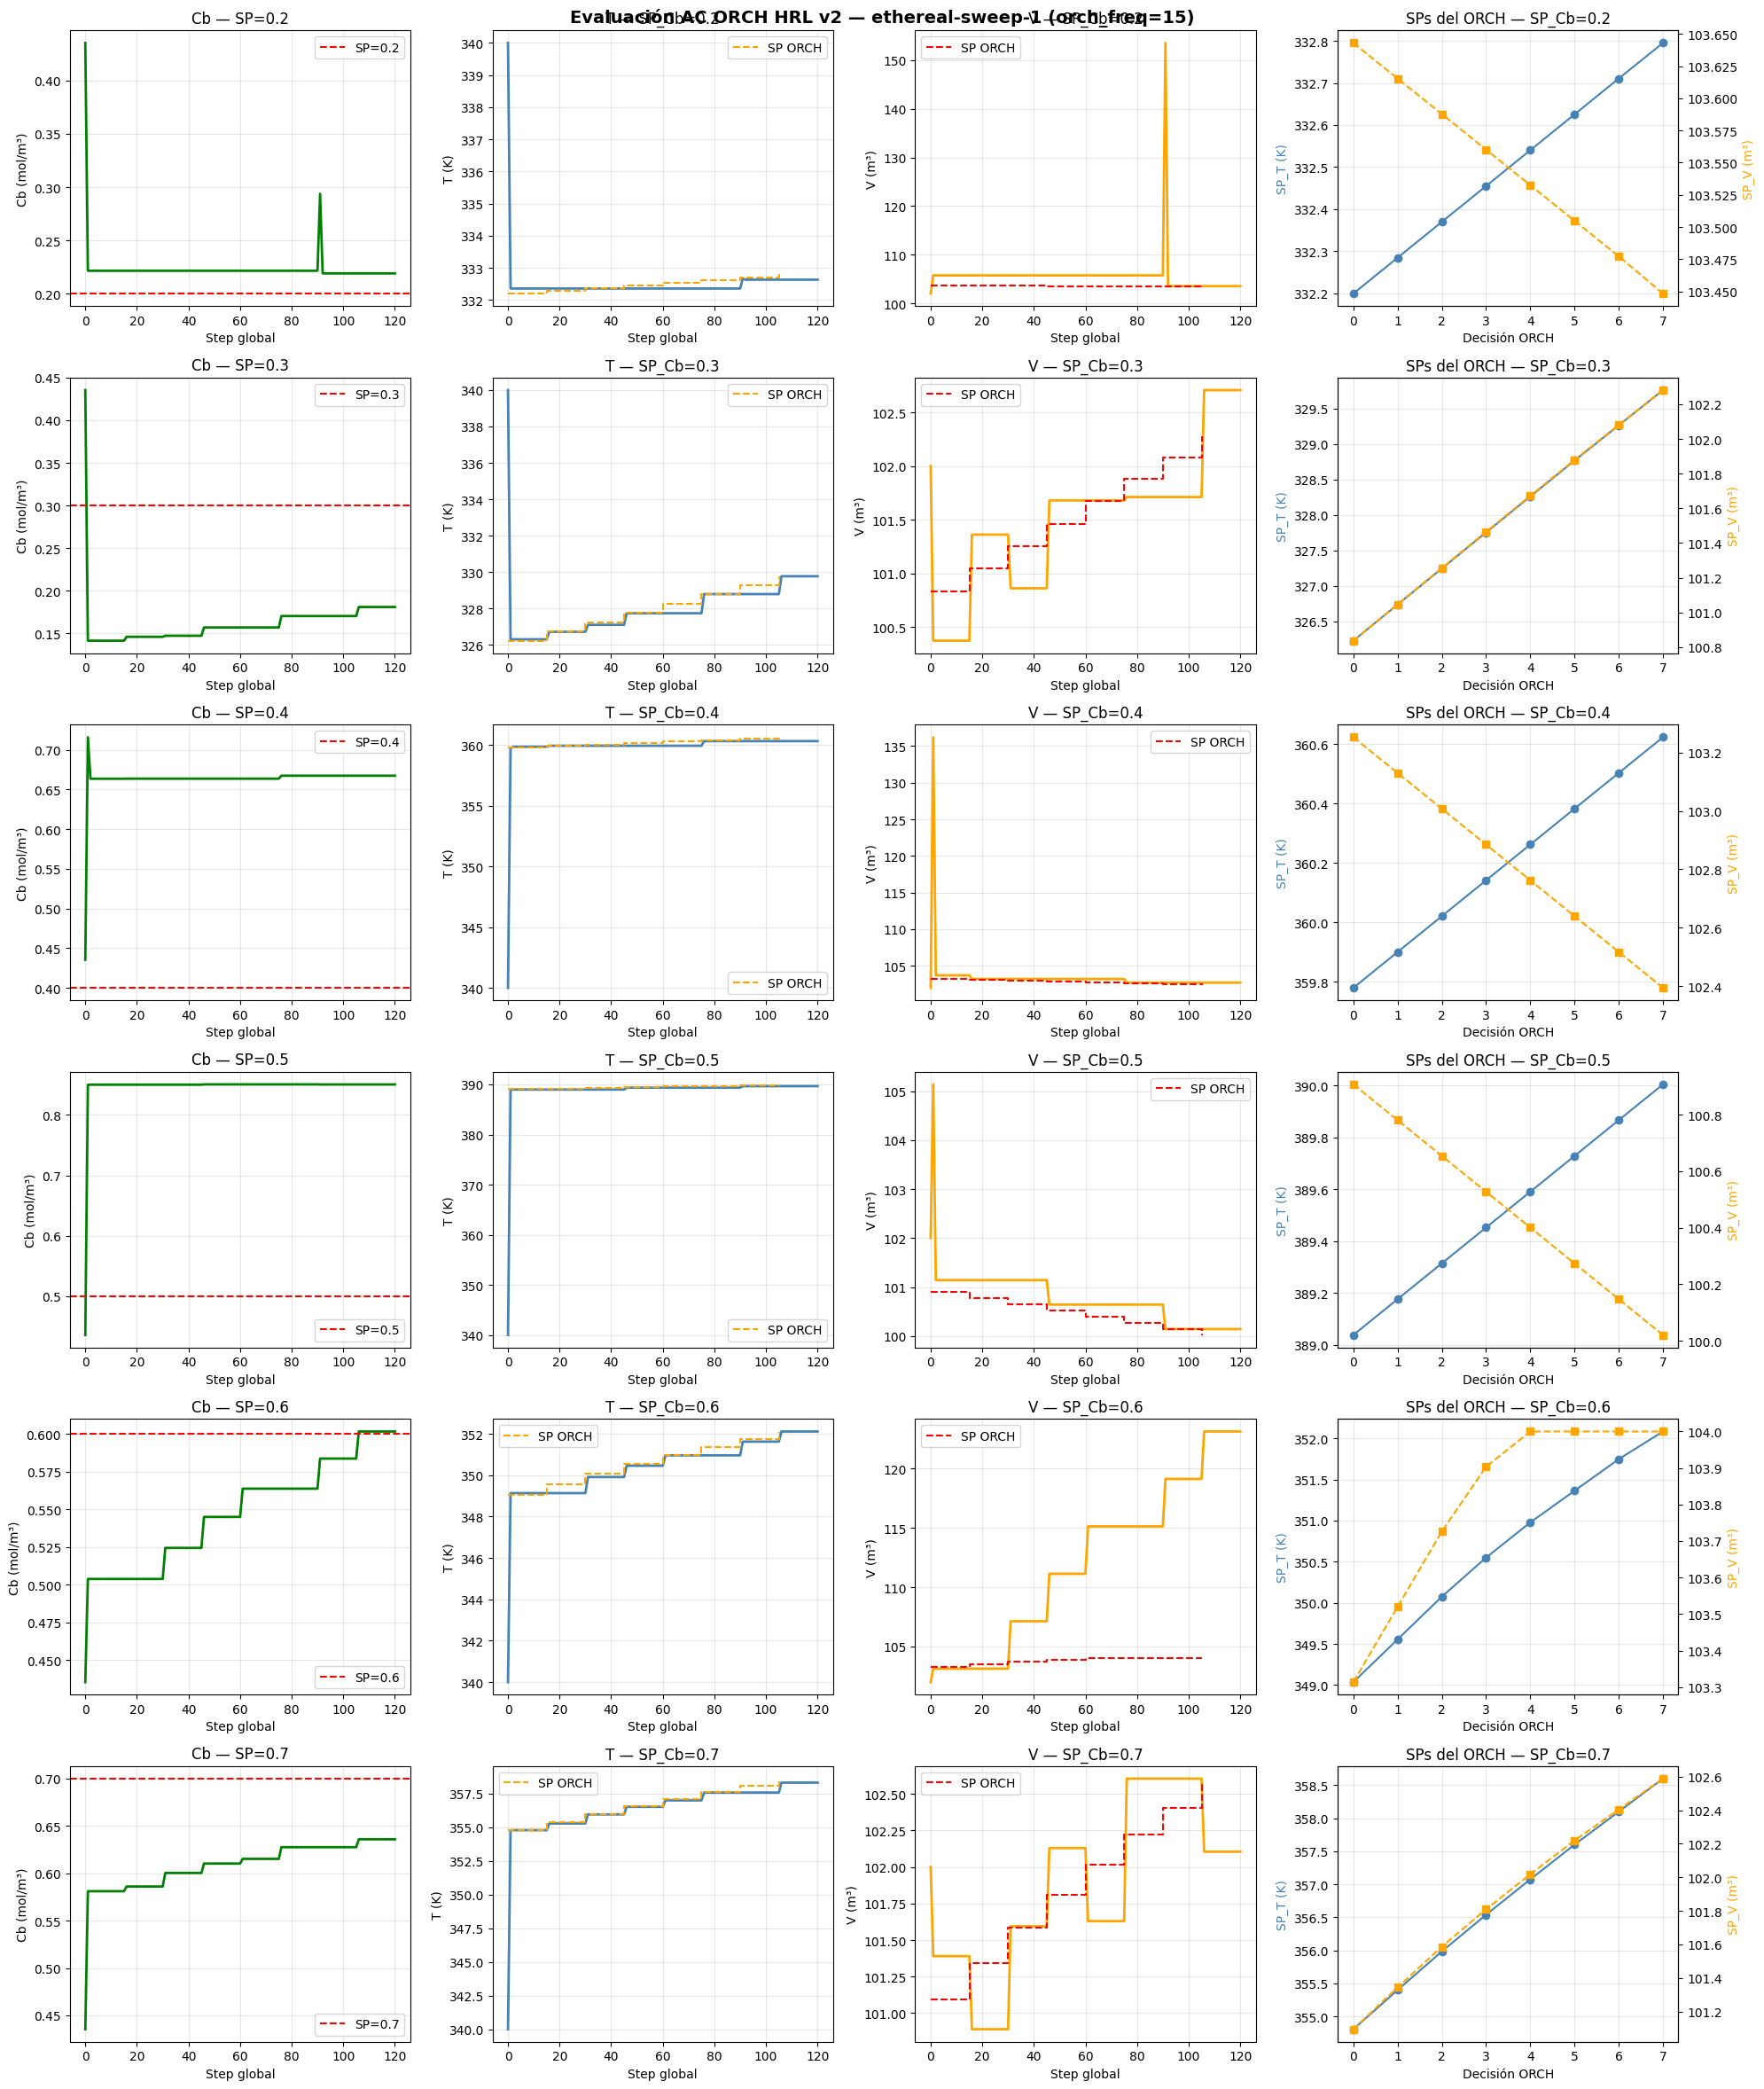

In [8]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH HRL v2 — ethereal-sweep-1 (orch_freq=15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2   laced-sweep-2


In [6]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_laced-sweep-2:latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 30
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH   # 120

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (64, 32),
        'lr_actor'     : 1e-05,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.05,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 200,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_laced-sweep-2:v3/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_laced-sweep-2:v3/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_laced-sweep-2:v3/agent_orch_best.pt
Agentes cargados
orch_freq=30 | max_steps=240 | decisiones ORCH/ep=8



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=311.3K  SP_V=102.17m³ | Cb=0.0647
  Step  30 | ORCH actúa → SP_T=311.5K  SP_V=102.26m³ | Cb=0.0640
  Step  60 | ORCH actúa → SP_T=311.6K  SP_V=102.36m³ | Cb=0.0706
  Step  90 | ORCH actúa → SP_T=311.8K  SP_V=102.45m³ | Cb=0.0685
  Step 120 | ORCH actúa → SP_T=312.0K  SP_V=102.54m³ | Cb=0.0685
  Step 150 | ORCH actúa → SP_T=312.1K  SP_V=102.64m³ | Cb=0.0685
  Step 180 | ORCH actúa → SP_T=312.3K  SP_V=102.73m³ | Cb=0.0686
  Step 210 | ORCH actúa → SP_T=312.4K  SP_V=102.82m³ | Cb=0.0687
  → Cb_final=0.0688 | Error=0.1312

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=397.0K  SP_V=99.94m³ | Cb=0.8431
  Step  30 | ORCH actúa → SP_T=397.0K  SP_V=99.92m³ | Cb=0.8431
  Step  60 | ORCH actúa → SP_T=396.9K  SP_V=99.91m³ | Cb=0.8431
  Step  90 | ORCH actúa → SP_T=396.9K  SP_V=99.90m³ | Cb=0.8431
  Step 120 | ORCH actúa → SP_T=396.9K  SP_V=99.88m³ | Cb=0.8431
 

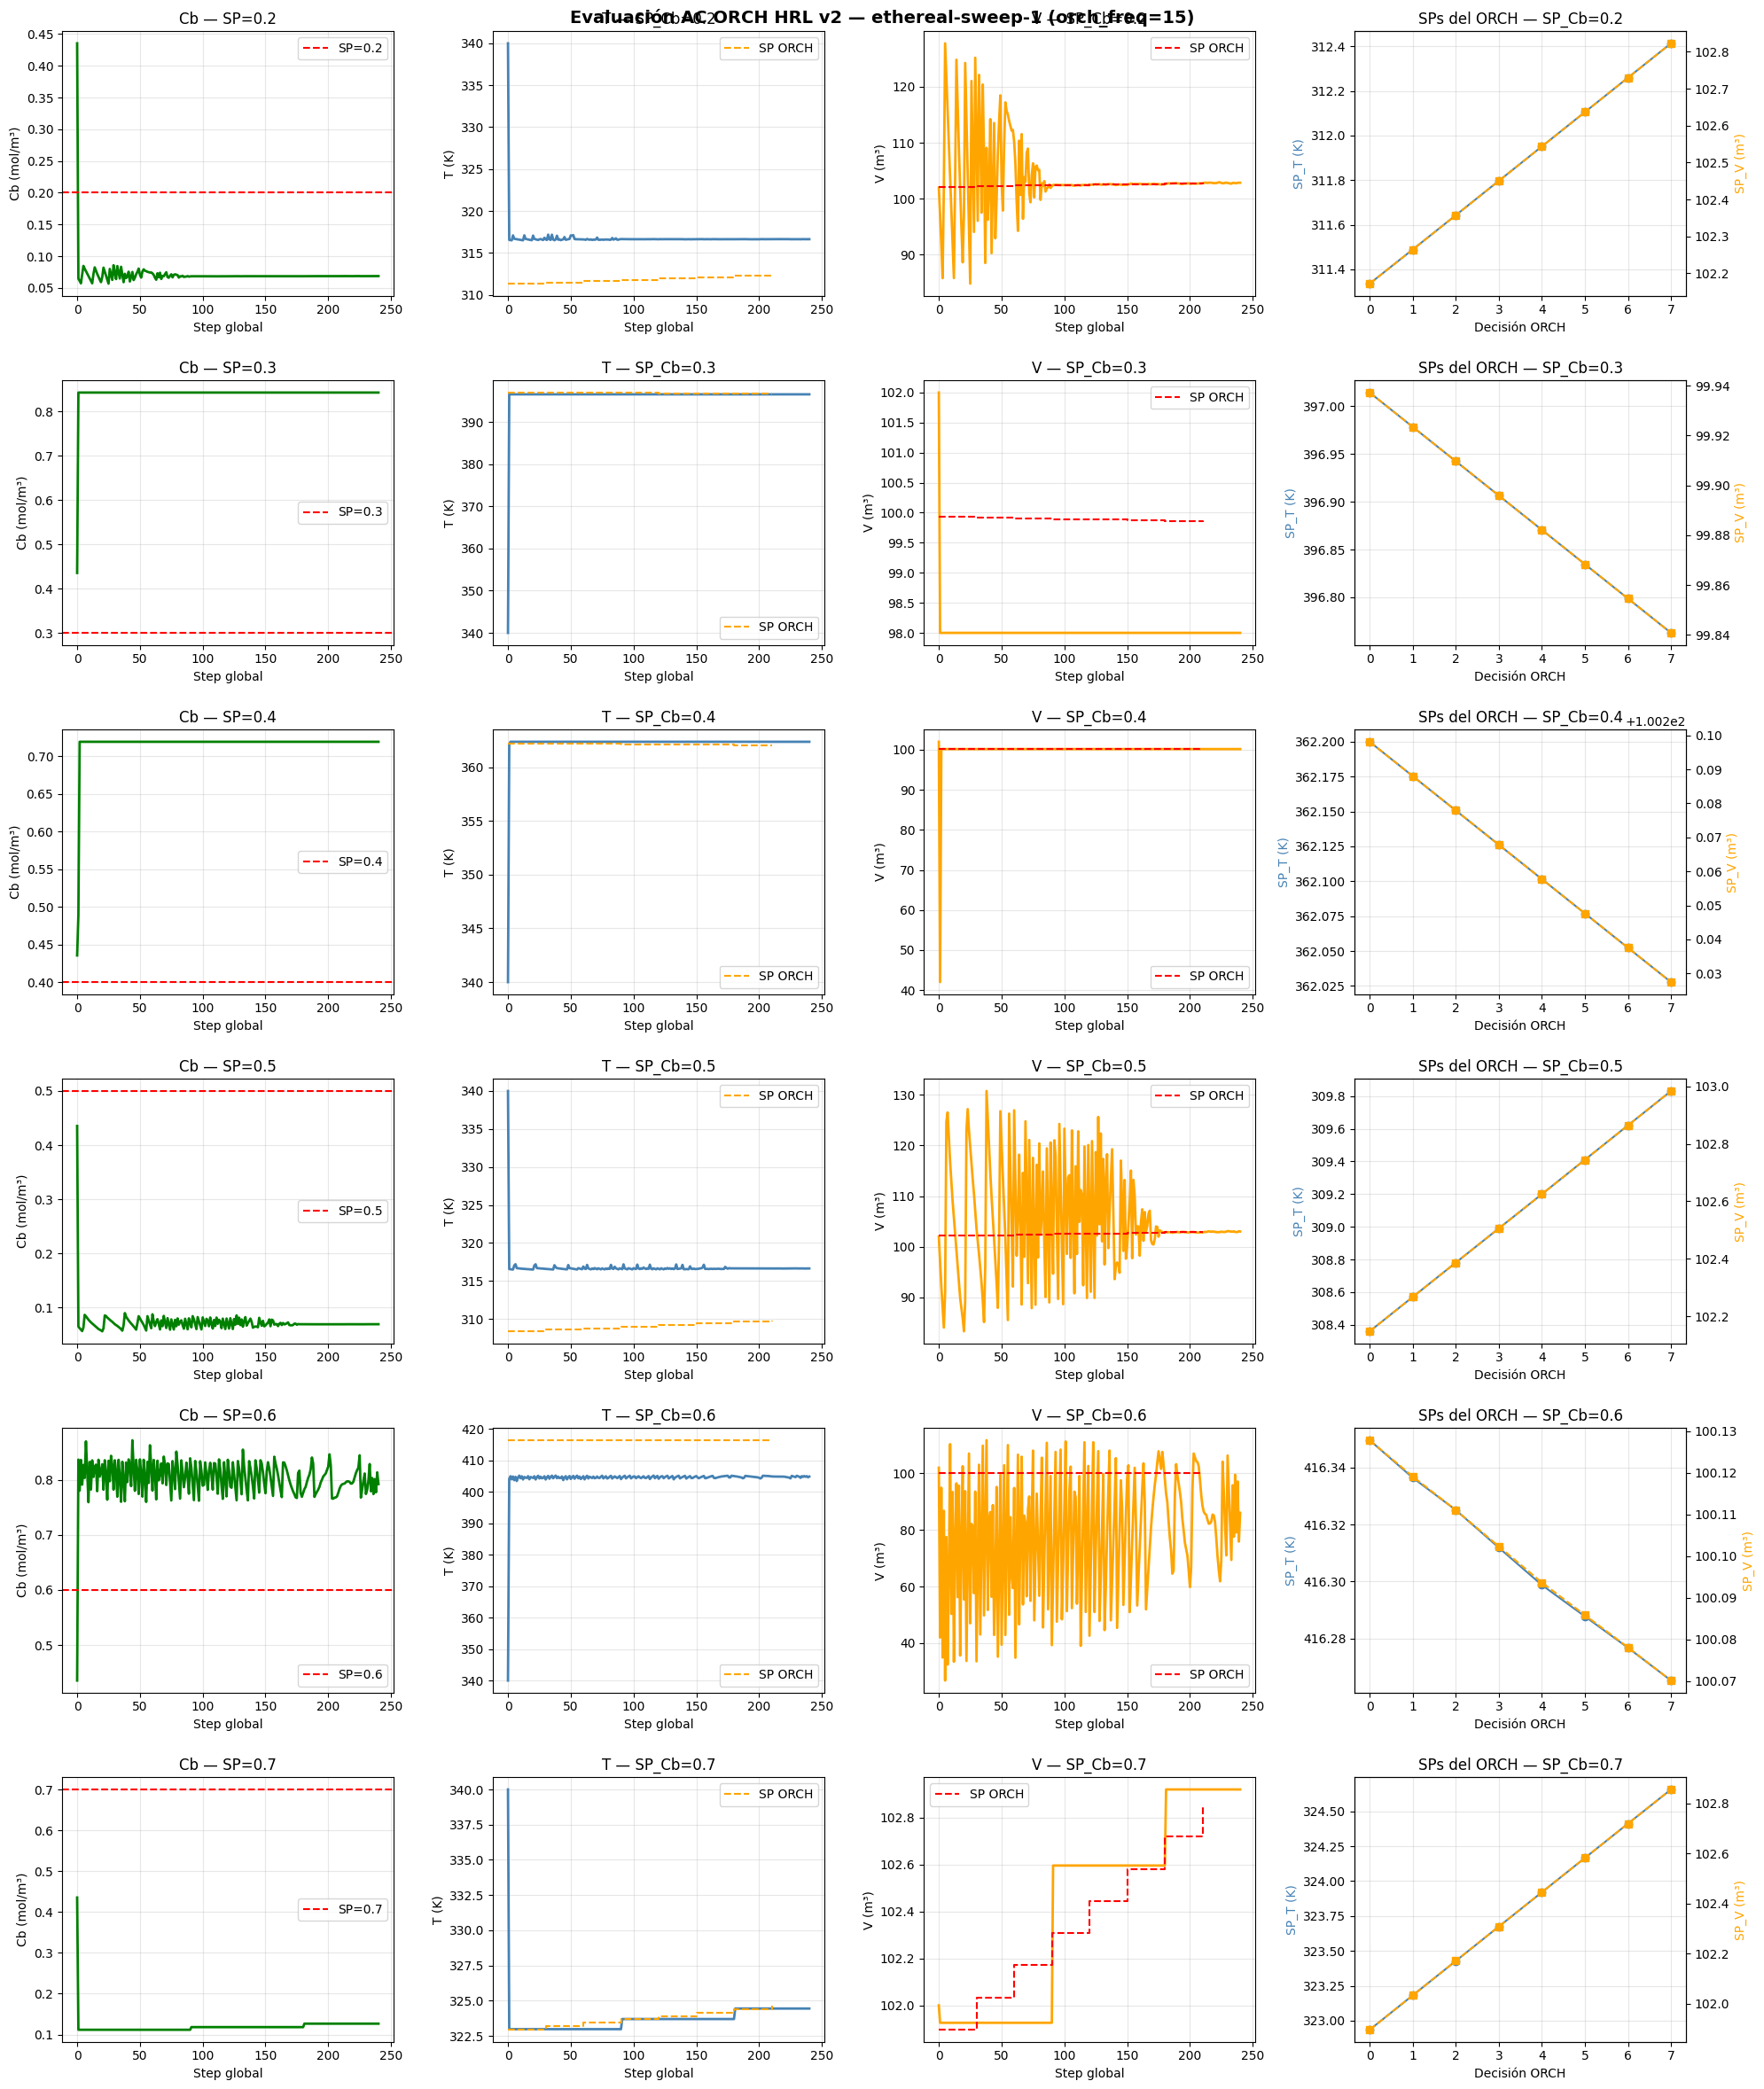

In [8]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH HRL v2 — ethereal-sweep-1 (orch_freq=15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 resilient-sweep-3

In [9]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_resilient-sweep-3:latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 30
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (64, 32),
        'lr_actor'     : 1e-05,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.05,
        'batch_size'   : 128,
        'buffer_size'  : 50000,
        'warmup_steps' : 500,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_resilient-sweep-3:v2/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_resilient-sweep-3:v2/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_resilient-sweep-3:v2/agent_orch_best.pt
Agentes cargados
orch_freq=30 | max_steps=240 | decisiones ORCH/ep=8



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=408.8K  SP_V=101.23m³ | Cb=0.7750
  Step  30 | ORCH actúa → SP_T=409.0K  SP_V=101.34m³ | Cb=0.8035
  Step  60 | ORCH actúa → SP_T=409.2K  SP_V=101.46m³ | Cb=0.8102
  Step  90 | ORCH actúa → SP_T=409.5K  SP_V=101.57m³ | Cb=0.7804
  Step 120 | ORCH actúa → SP_T=409.7K  SP_V=101.69m³ | Cb=0.7703
  Step 150 | ORCH actúa → SP_T=409.9K  SP_V=101.80m³ | Cb=0.7766
  Step 180 | ORCH actúa → SP_T=410.2K  SP_V=101.92m³ | Cb=0.7765
  Step 210 | ORCH actúa → SP_T=410.4K  SP_V=102.03m³ | Cb=0.7762
  → Cb_final=0.7762 | Error=0.5762

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=375.0K  SP_V=101.95m³ | Cb=0.8154
  Step  30 | ORCH actúa → SP_T=375.2K  SP_V=102.08m³ | Cb=0.8154
  Step  60 | ORCH actúa → SP_T=375.5K  SP_V=102.21m³ | Cb=0.8154
  Step  90 | ORCH actúa → SP_T=375.7K  SP_V=102.34m³ | Cb=0.8204
  Step 120 | ORCH actúa → SP_T=376.0K  SP_V=102.47m³ | Cb=0.8

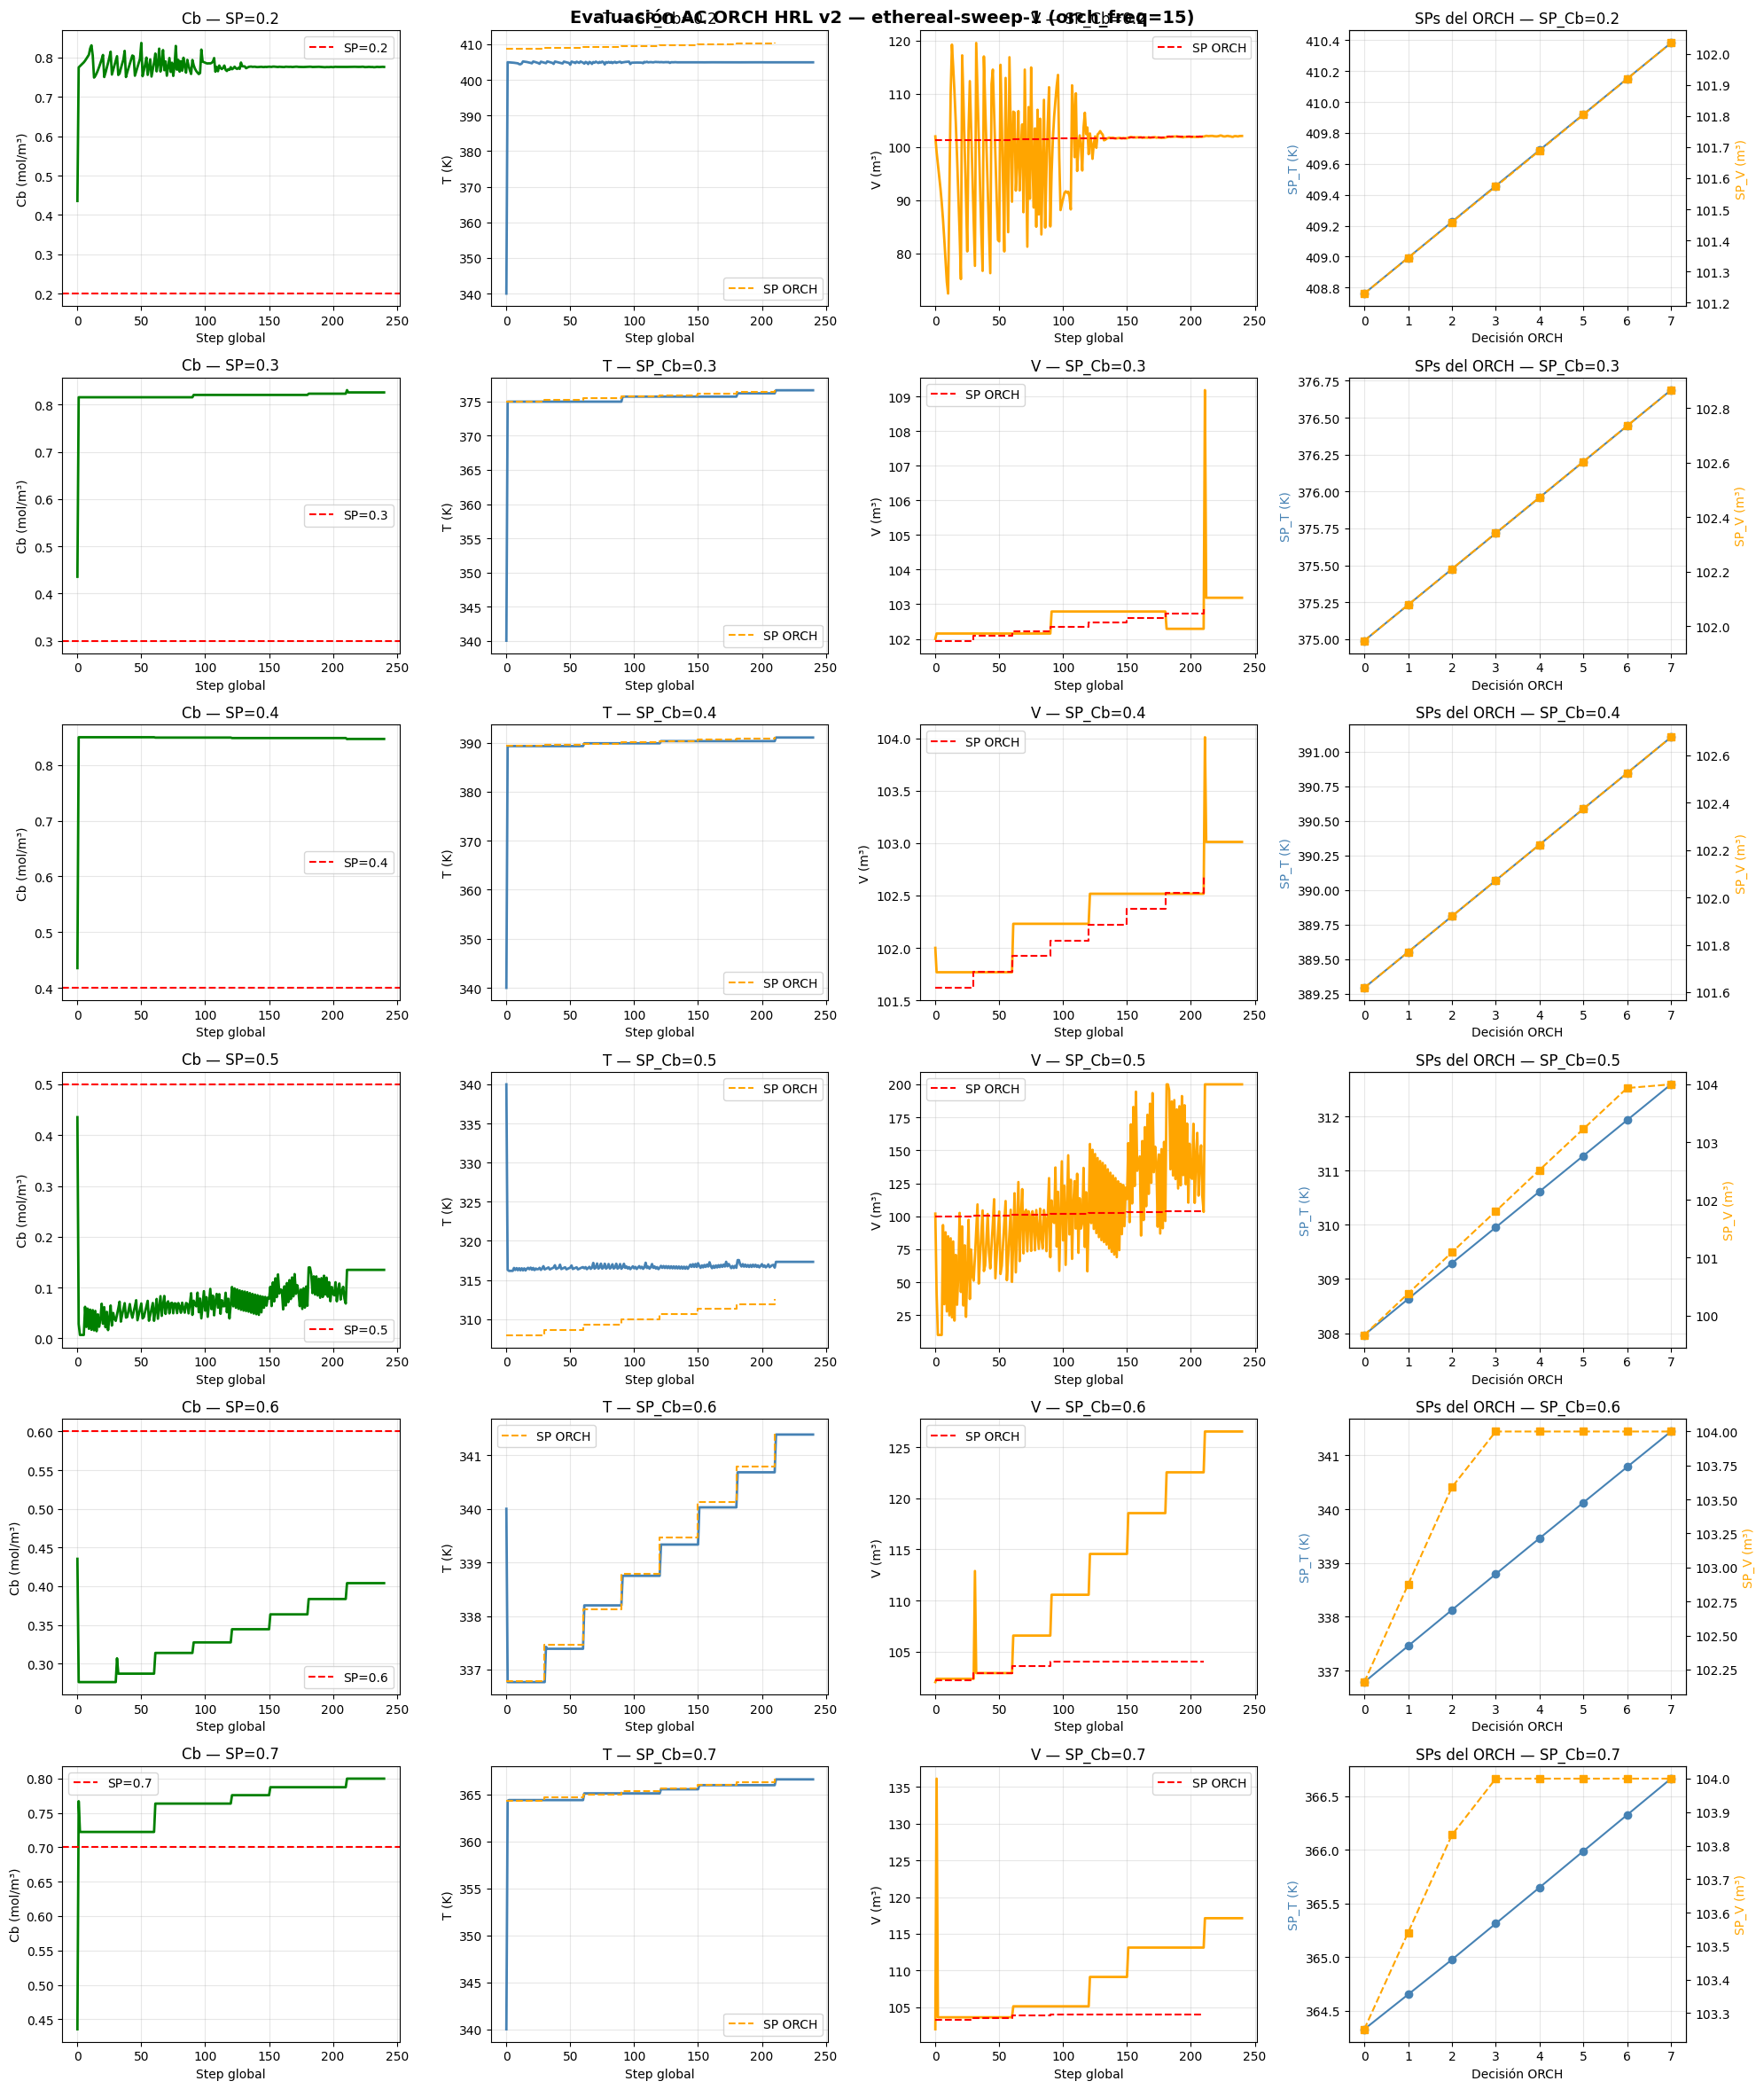

In [10]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH HRL v2 — ethereal-sweep-1 (orch_freq=15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()

###6.4. summer-sweep-4

In [11]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_summer-sweep-4 :latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 30
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH   # 120

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (64, 32),
        'lr_actor'     : 1e-05,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.05,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 500,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_summer-sweep-4:v2/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_summer-sweep-4:v2/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_summer-sweep-4:v2/agent_orch_best.pt
Agentes cargados
orch_freq=30 | max_steps=240 | decisiones ORCH/ep=8



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=369.2K  SP_V=101.95m³ | Cb=0.7706
  Step  30 | ORCH actúa → SP_T=369.3K  SP_V=102.10m³ | Cb=0.7706
  Step  60 | ORCH actúa → SP_T=369.4K  SP_V=102.25m³ | Cb=0.7706
  Step  90 | ORCH actúa → SP_T=369.5K  SP_V=102.40m³ | Cb=0.7706
  Step 120 | ORCH actúa → SP_T=369.6K  SP_V=102.55m³ | Cb=0.7706
  Step 150 | ORCH actúa → SP_T=369.7K  SP_V=102.70m³ | Cb=0.7825
  Step 180 | ORCH actúa → SP_T=369.8K  SP_V=102.85m³ | Cb=0.7774
  Step 210 | ORCH actúa → SP_T=369.9K  SP_V=103.01m³ | Cb=0.7774
  → Cb_final=0.7774 | Error=0.5774

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=326.5K  SP_V=100.93m³ | Cb=0.1461
  Step  30 | ORCH actúa → SP_T=326.8K  SP_V=101.40m³ | Cb=0.1432
  Step  60 | ORCH actúa → SP_T=327.2K  SP_V=101.87m³ | Cb=0.1510
  Step  90 | ORCH actúa → SP_T=327.5K  SP_V=102.34m³ | Cb=0.1510
  Step 120 | ORCH actúa → SP_T=327.8K  SP_V=102.82m³ | Cb=0.1

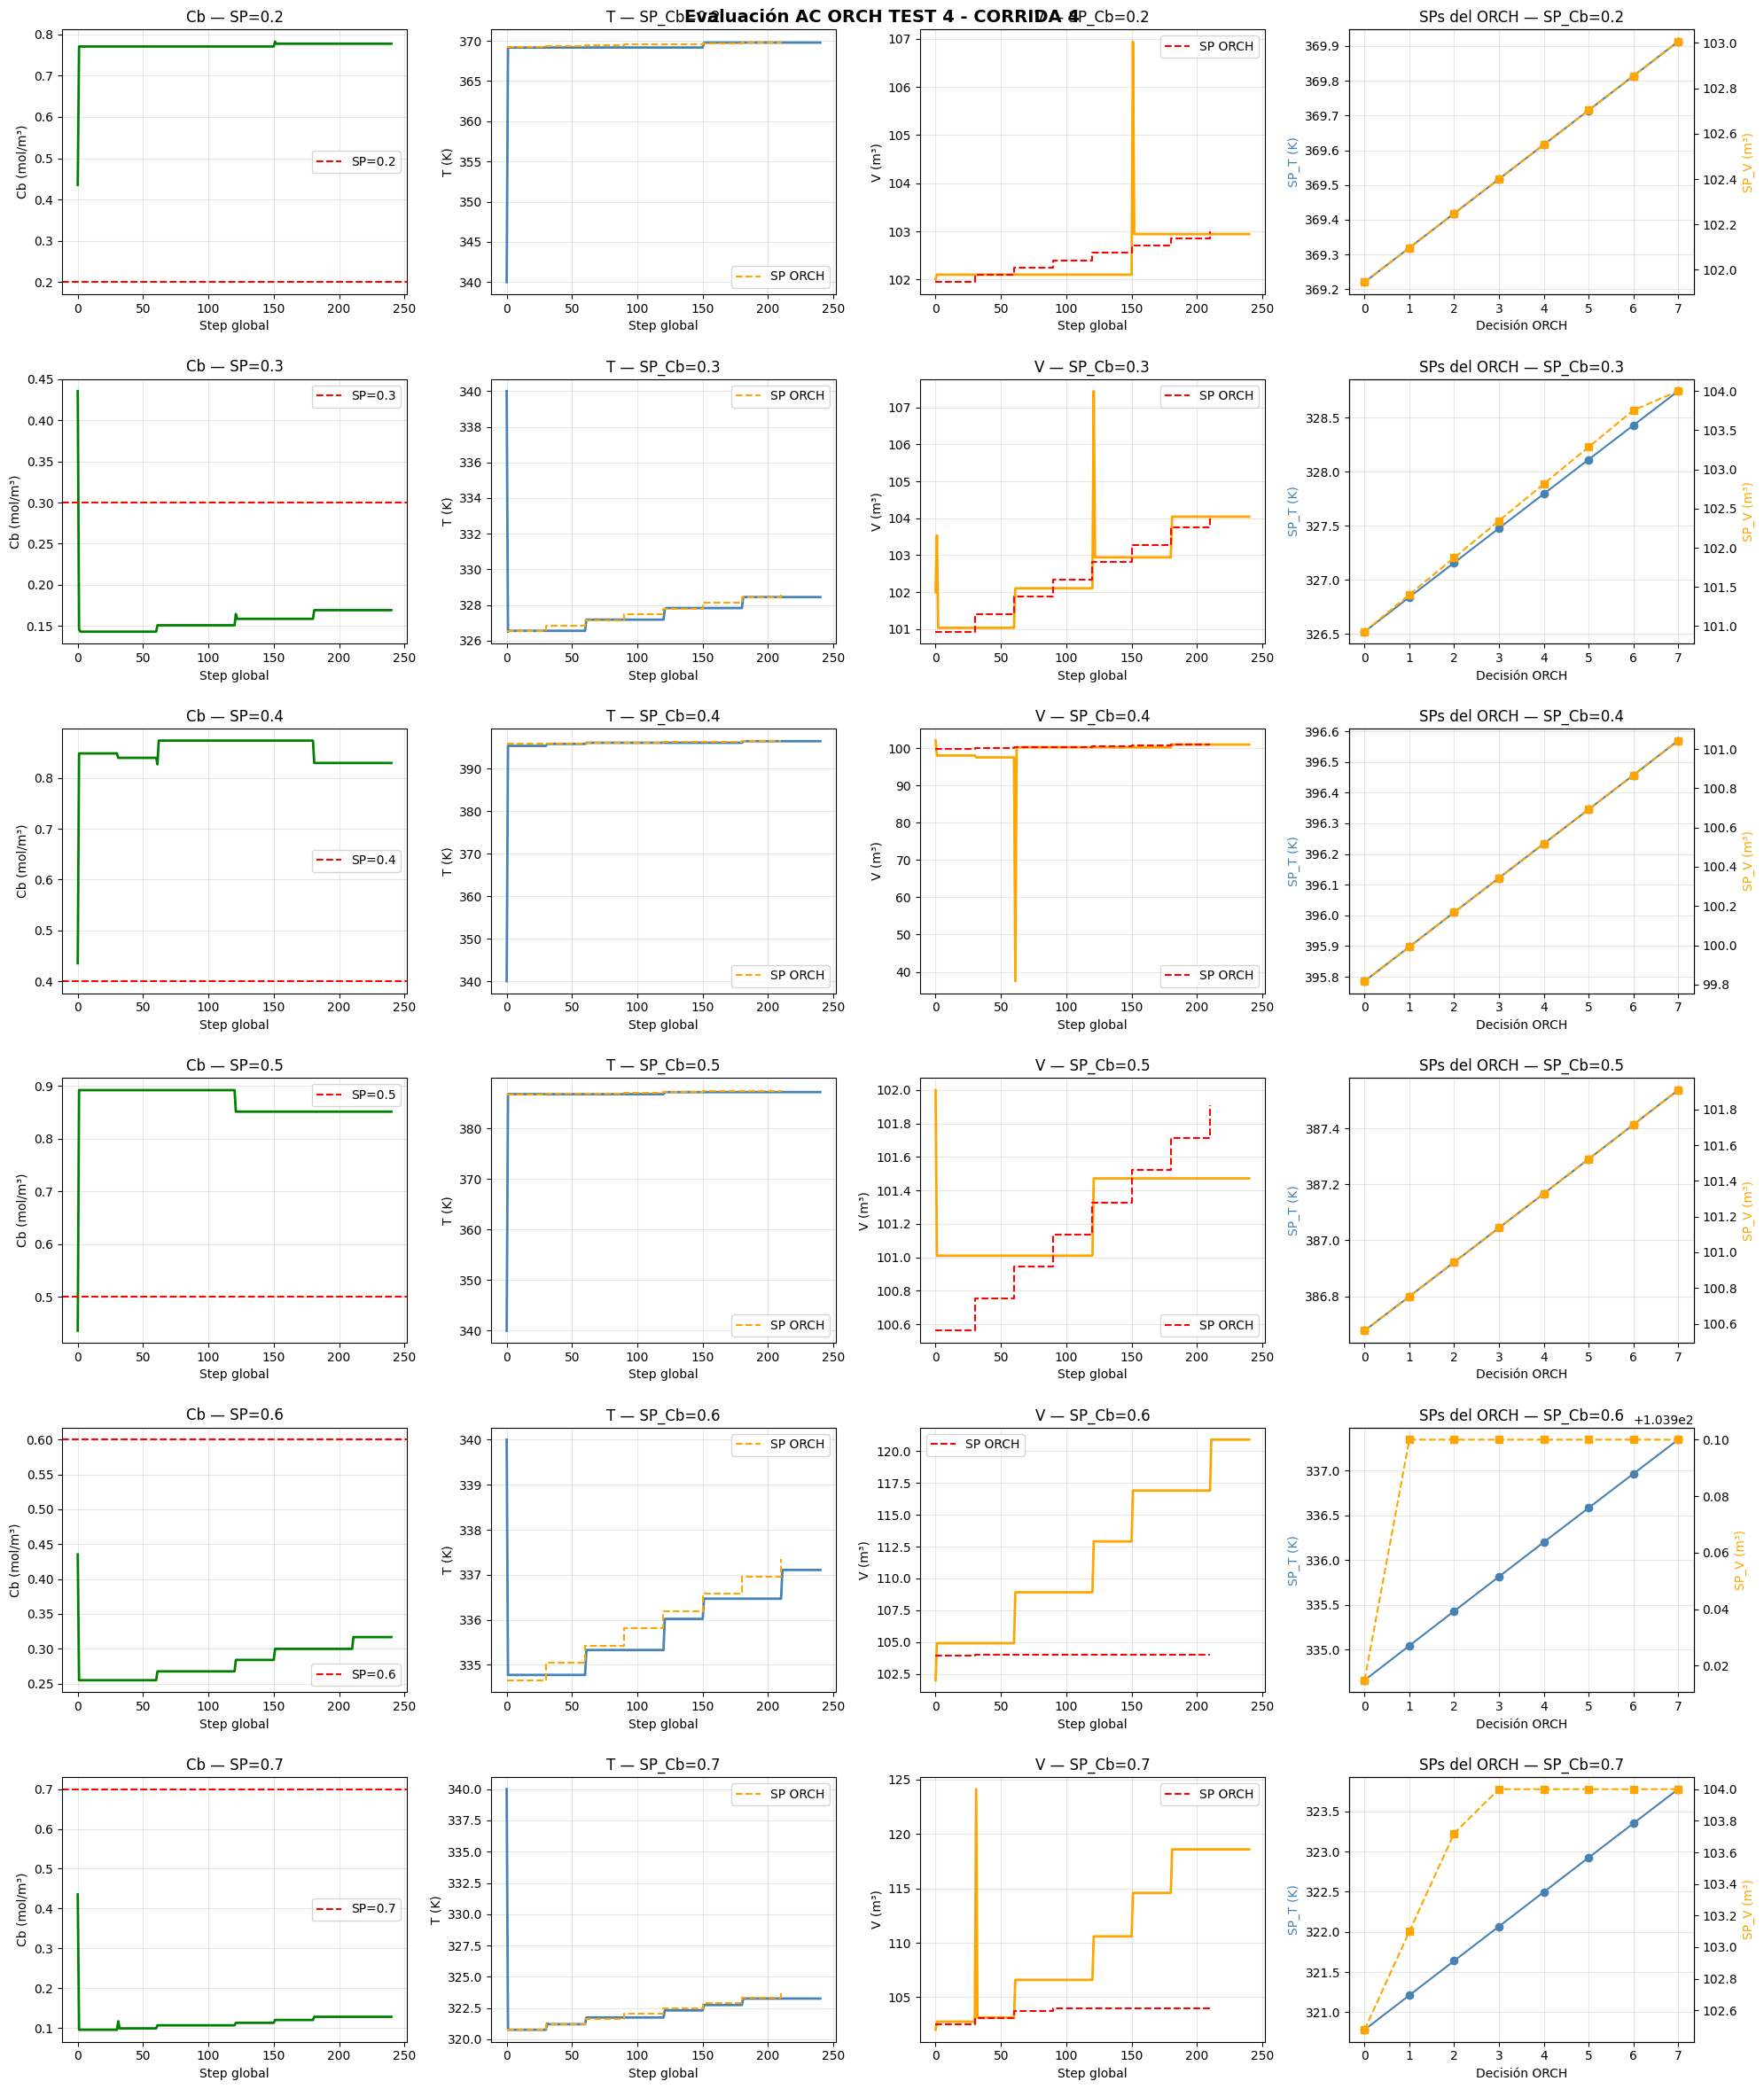

In [12]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH TEST 4 - CORRIDA 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5  major-sweep-1

In [13]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_major-sweep-1:latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 15
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH   # 120

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (128, 64),
        'lr_actor'     : 1e-04,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.05,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 200,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_major-sweep-1:v3/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_major-sweep-1:v3/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_major-sweep-1:v3/agent_orch_best.pt
Agentes cargados
orch_freq=15 | max_steps=120 | decisiones ORCH/ep=8



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=355.5K  SP_V=100.69m³ | Cb=0.6147
  Step  15 | ORCH actúa → SP_T=354.6K  SP_V=99.69m³ | Cb=0.5748
  Step  30 | ORCH actúa → SP_T=353.6K  SP_V=99.50m³ | Cb=0.5629
  Step  45 | ORCH actúa → SP_T=352.6K  SP_V=99.50m³ | Cb=0.5471
  Step  60 | ORCH actúa → SP_T=351.6K  SP_V=99.50m³ | Cb=0.5304
  Step  75 | ORCH actúa → SP_T=350.6K  SP_V=99.50m³ | Cb=0.5113
  Step  90 | ORCH actúa → SP_T=349.6K  SP_V=99.50m³ | Cb=0.4938
  Step 105 | ORCH actúa → SP_T=348.7K  SP_V=99.50m³ | Cb=0.4749
  → Cb_final=0.4749 | Error=0.2749

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=403.5K  SP_V=100.40m³ | Cb=0.8474
  Step  15 | ORCH actúa → SP_T=402.6K  SP_V=99.50m³ | Cb=0.7911
  Step  30 | ORCH actúa → SP_T=401.6K  SP_V=99.50m³ | Cb=0.7957
  Step  45 | ORCH actúa → SP_T=400.6K  SP_V=99.50m³ | Cb=0.8014
  Step  60 | ORCH actúa → SP_T=399.6K  SP_V=99.50m³ | Cb=0.8076
  Step 

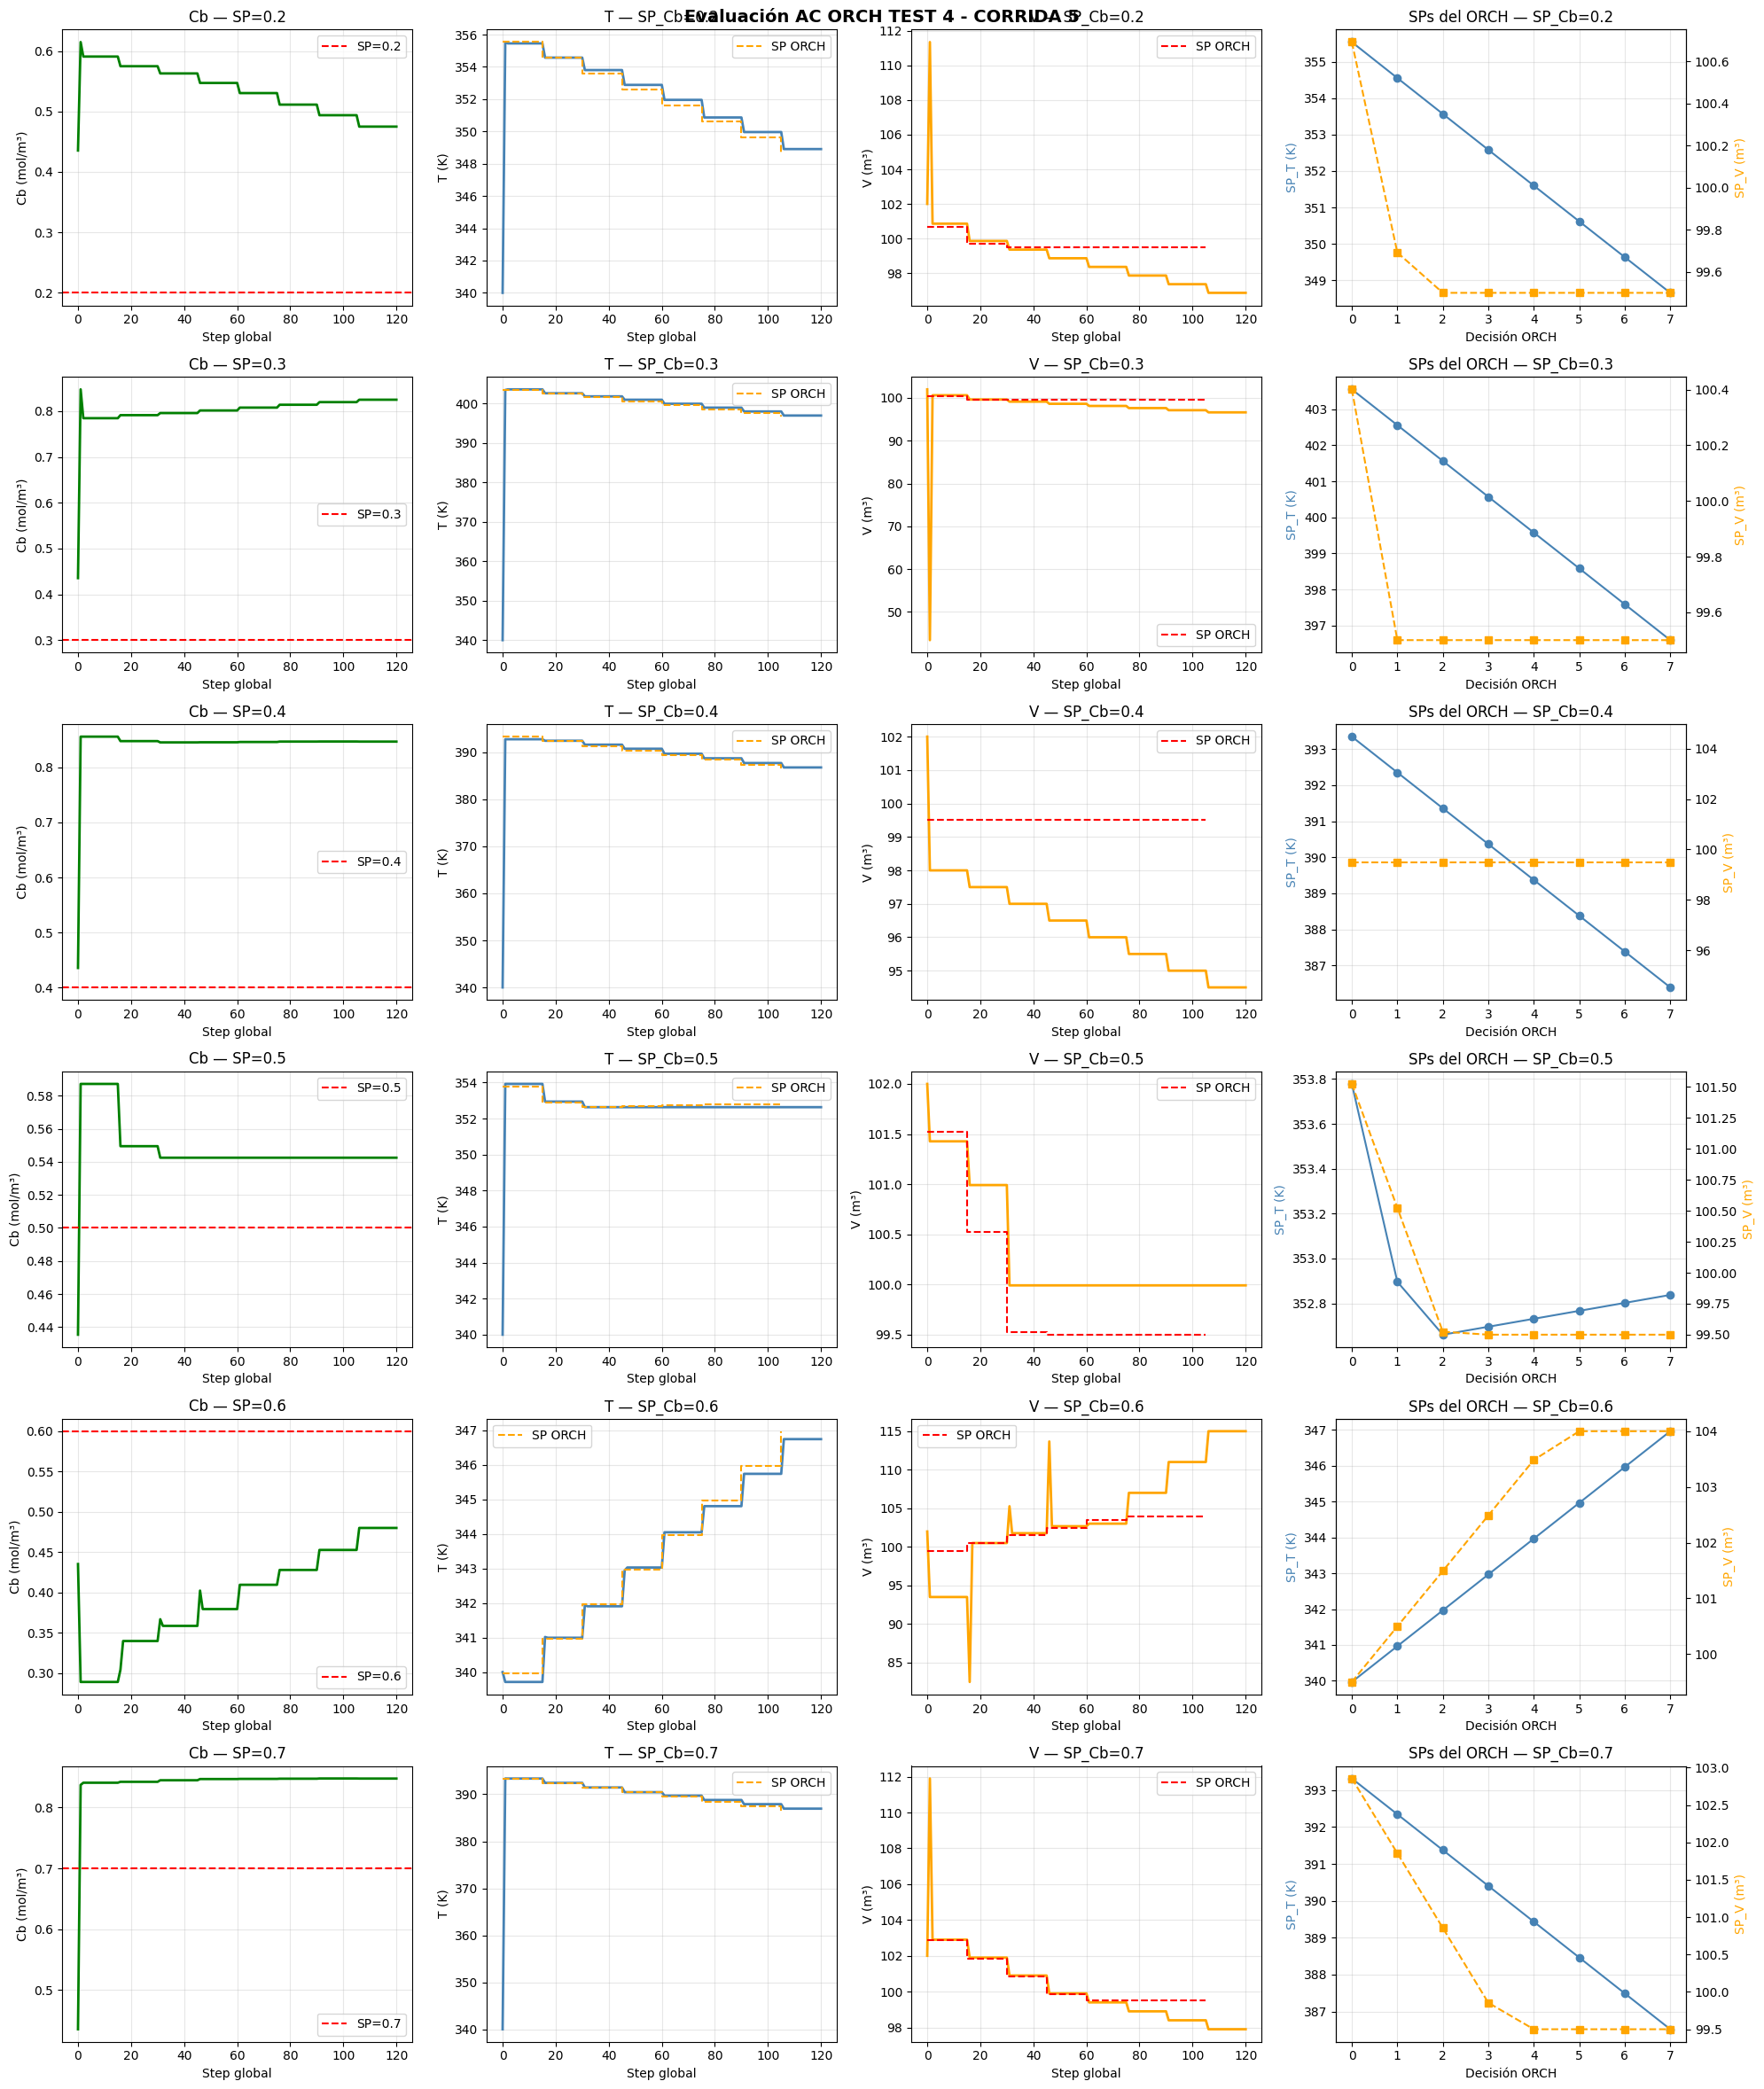

In [14]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH TEST 4 - CORRIDA 5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()

###6.6 serene-sweep-2

In [15]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_ORCH_GRID_TEST_4/model_serene-sweep-2:latest')
artifact_dir = artifact.download()

DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
ORCH_FREQ          = 15
N_DEC_ORCH         = 8
MAX_STEPS          = ORCH_FREQ * N_DEC_ORCH   # 120

eval_config = {
    'env_config': {
        'architecture'             : 'jerarquica',
        'env_type'                 : 'simulation',
        'n_manipulable_vars'       : 2,
        'manipulable_ranges'       : MANIPULABLE_RANGES,
        'n_target_vars'            : 1,
        'target_ranges'            : [(0.0, 1.0)],
        'target_setpoints'         : [0.4],
        'target_working_ranges'    : [(0.0, 2.0)],
        'dt_usuario'               : 1.0,
        'max_steps'                : MAX_STEPS,
        'orch_freq'                : ORCH_FREQ,
        'max_time_detector'        : 120,
        'reward_dead_band'         : 0.02,
        'delta_percent_ctrl'       : 0.05,
        'delta_percent_orch'       : 0.05,
        'reward_weights'           : {'error': 1.0, 'tiempo': 0.001, 'overshoot': 0.3, 'energy': 0.001},
        'pid_limits'               : [(0.01, 5.0), (0.001, 1.0), (0.0, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'continuous'},
        'env_type_config'          : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'         : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.05,
            'abrupt_change_threshold' : 0.5,
        },
    },
    'ctrl_checkpoint_path': f'{artifact_dir}/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'algorithm'  : 'ac',
        'state_dim'  : 10,
        'action_dim' : 6,
        'n_vars'     : 2,
        'action_type': 'continuous',
        'hidden_dims': (256, 128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'algorithm'    : 'ac',
        'state_dim'    : 5,
        'action_dim'   : 3,
        'n_vars'       : 2,
        'action_type'  : 'continuous',
        'hidden_dims'  : (128, 64),
        'lr_actor'     : 1e-04,
        'lr_critic'    : 1e-03,
        'gamma'        : 0.99,
        'entropy_coef' : 0.01,
        'batch_size'   : 64,
        'buffer_size'  : 10000,
        'warmup_steps' : 200,
        'device'       : DEVICE,
        'seed'         : 42,
    },
    'n_episodes'                  : 1,
    'max_steps_per_episode'       : MAX_STEPS,
    'eval_frequency'              : 9999,
    'log_frequency'               : 1,
    'save_frequency'              : 9999,
    'checkpoint_dir'              : 'checkpoints/eval_tmp',
    'early_stopping_patience'     : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb'                   : False,
}

cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(cstr)
trainer_eval.agent_orch.load(f'{artifact_dir}/agent_orch_best.pt')
print('Agentes cargados')
print(f'orch_freq={ORCH_FREQ} | max_steps={MAX_STEPS} | decisiones ORCH/ep={N_DEC_ORCH}')

wandb:   2 of 2 files downloaded.  


Cargando agente CTRL pre-entrenado desde: /content/artifacts/model_serene-sweep-2:v2/agent_ctrl_best.pt
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_serene-sweep-2:v2/agent_ctrl_best.pt
AC Estocástico creado | role=orch | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_serene-sweep-2:v2/agent_orch_best.pt
Agentes cargados
orch_freq=15 | max_steps=120 | decisiones ORCH/ep=8



SP_Cb=0.2 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=330.2K  SP_V=100.70m³ | Cb=0.1982
  Step  15 | ORCH actúa → SP_T=331.1K  SP_V=100.03m³ | Cb=0.1862
  Step  30 | ORCH actúa → SP_T=331.9K  SP_V=99.50m³ | Cb=0.1937
  Step  45 | ORCH actúa → SP_T=332.5K  SP_V=99.50m³ | Cb=0.2016
  Step  60 | ORCH actúa → SP_T=332.7K  SP_V=99.50m³ | Cb=0.2016
  Step  75 | ORCH actúa → SP_T=332.9K  SP_V=99.50m³ | Cb=0.2082
  Step  90 | ORCH actúa → SP_T=332.8K  SP_V=99.50m³ | Cb=0.2082
  Step 105 | ORCH actúa → SP_T=332.8K  SP_V=99.50m³ | Cb=0.2082
  → Cb_final=0.2082 | Error=0.0082

SP_Cb=0.3 | Estado inicial: Cb=0.435 | T=340.0K | V=102.00m³
  Step   0 | ORCH actúa → SP_T=405.2K  SP_V=101.21m³ | Cb=0.7719
  Step  15 | ORCH actúa → SP_T=404.2K  SP_V=100.21m³ | Cb=0.8372
  Step  30 | ORCH actúa → SP_T=403.2K  SP_V=99.50m³ | Cb=0.7865
  Step  45 | ORCH actúa → SP_T=402.2K  SP_V=99.50m³ | Cb=0.7908
  Step  60 | ORCH actúa → SP_T=401.2K  SP_V=99.50m³ | Cb=0.7967
  Ste

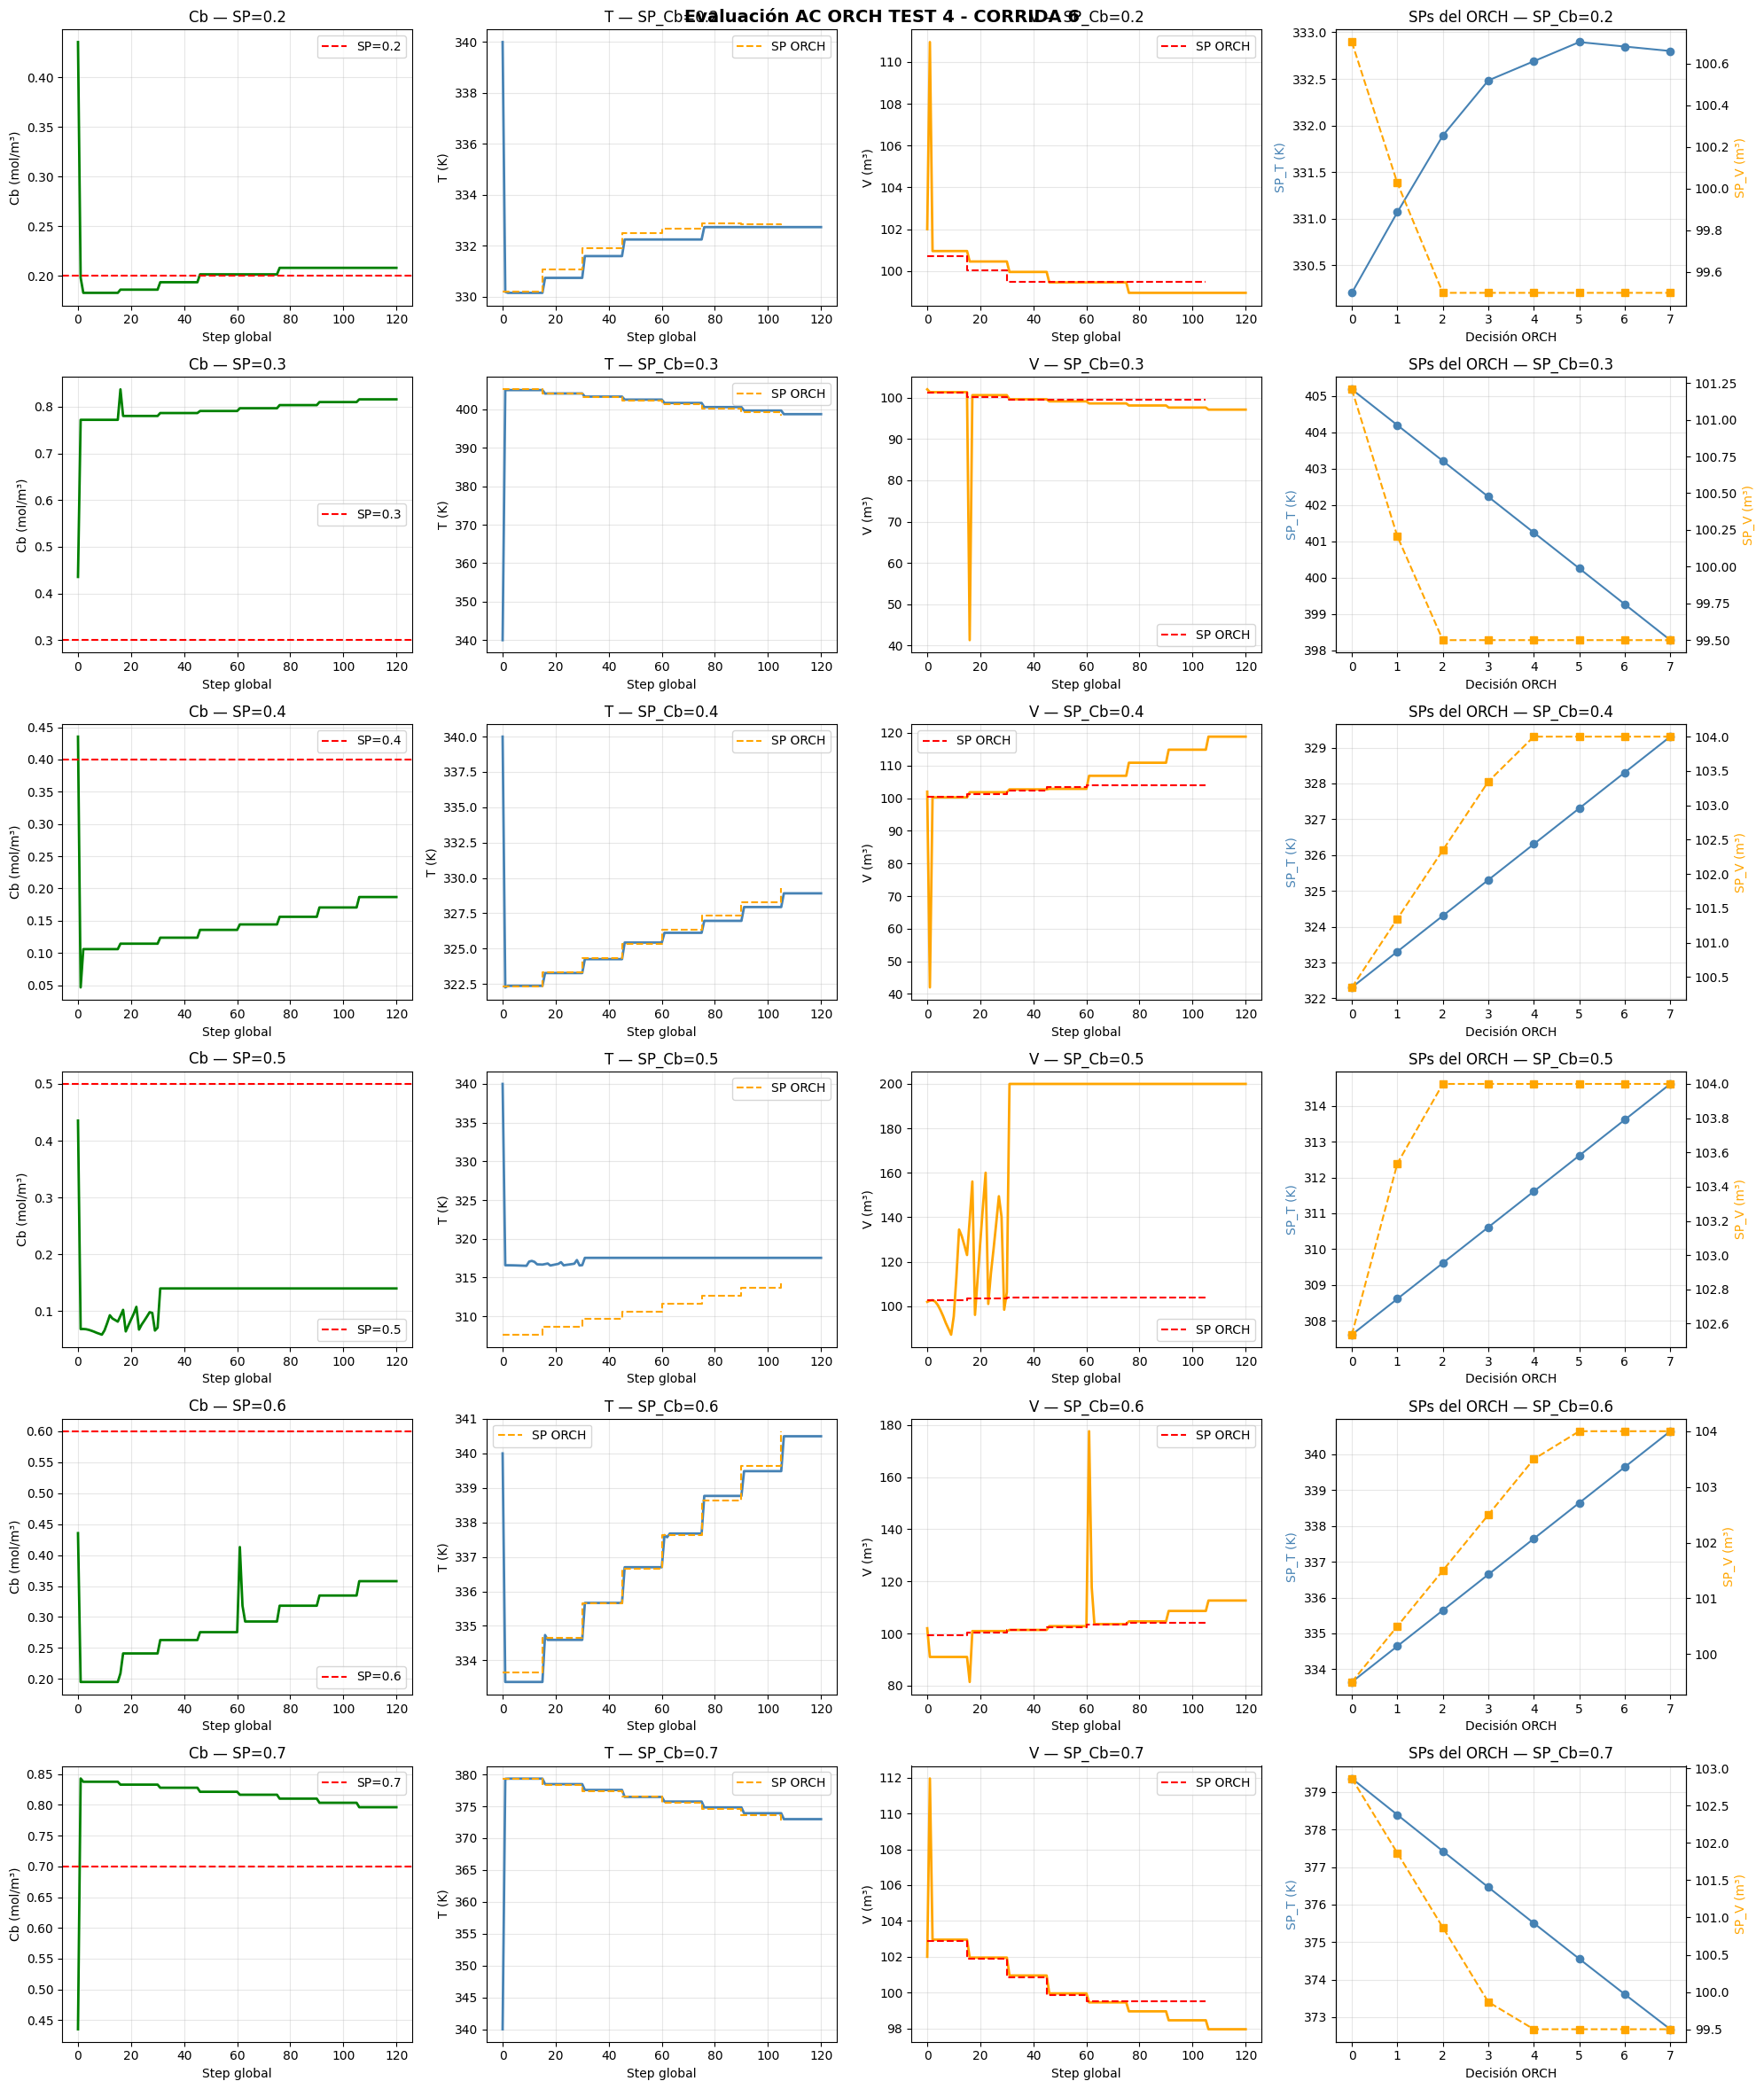

In [16]:
# ============ GRILLA DE Cb Y GRAFICOS ============
Cb_setpoints = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(len(Cb_setpoints), 4, figsize=(20, 4 * len(Cb_setpoints)))

for i, cb_sp in enumerate(Cb_setpoints):
    cb_traj, T_traj, V_traj, SP_T, SP_V = evaluar_cb(trainer_eval, cb_sp)
    steps = np.arange(len(cb_traj))

    # Cb
    axes[i, 0].plot(steps, cb_traj, color='green', linewidth=2)
    axes[i, 0].axhline(cb_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={cb_sp}')
    axes[i, 0].set_title(f'Cb — SP={cb_sp}')
    axes[i, 0].set_ylabel('Cb (mol/m³)')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    # T con los SPs que pidió el ORCH marcados
    axes[i, 1].plot(steps, T_traj, color='steelblue', linewidth=2)
    if SP_T:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_T))]
        axes[i, 1].step(sp_steps, SP_T, color='orange', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 1].legend()
    axes[i, 1].set_title(f'T — SP_Cb={cb_sp}')
    axes[i, 1].set_ylabel('T (K)'); axes[i, 1].grid(True, alpha=0.3)

    # V con los SPs que pidió el ORCH marcados
    axes[i, 2].plot(steps, V_traj, color='orange', linewidth=2)
    if SP_V:
        sp_steps = [j * ORCH_FREQ for j in range(len(SP_V))]
        axes[i, 2].step(sp_steps, SP_V, color='red', linewidth=1.5,
                        linestyle='--', where='post', label='SP ORCH')
        axes[i, 2].legend()
    axes[i, 2].set_title(f'V — SP_Cb={cb_sp}')
    axes[i, 2].set_ylabel('V (m³)'); axes[i, 2].grid(True, alpha=0.3)

    # SPs del ORCH a lo largo del episodio
    if SP_T and SP_V:
        dec_idx = np.arange(len(SP_T))
        axes[i, 3].plot(dec_idx, SP_T, 'o-', color='steelblue', label='SP_T')
        ax2 = axes[i, 3].twinx()
        ax2.plot(dec_idx, SP_V, 's--', color='orange', label='SP_V')
        axes[i, 3].set_title(f'SPs del ORCH — SP_Cb={cb_sp}')
        axes[i, 3].set_xlabel('Decisión ORCH')
        axes[i, 3].set_ylabel('SP_T (K)', color='steelblue')
        ax2.set_ylabel('SP_V (m³)', color='orange')
        axes[i, 3].grid(True, alpha=0.3)

    for ax in axes[i, :3]:
        ax.set_xlabel('Step global')

plt.suptitle('Evaluación AC ORCH TEST 4 - CORRIDA 6', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_orch_v2.png', dpi=150, bbox_inches='tight')
plt.show()